Strategy Definitions (for the review notebook)
Shared assumptions

Execution time: trade on day t at the close using that day’s price. Evaluation uses forward-only data (no peeking at t+1).

Fractional sizing: allowed, so pos_frac can be hit precisely.

Costs: slippage ±10 bps by default (BUY: price·(1+slip), SELL: price·(1−slip)), plus optional commissions (set to 0 unless changed).

Cash-flow aware performance: we track external deposits/withdrawals and compute time-weighted returns (TWR):

Daily TWR: r_t = (E_t − E_{t−1} − flow_t) / E_{t−1}.

This prevents deposits (e.g., new symbols joining) from inflating % returns.

Reporting: daily/weekly/monthly/yearly & all-time with Sharpe (annualized), CAGR (returns-based annualization on short windows), Max Drawdown, and XIRR (money-weighted) where applicable.

1) Buy & Hold (BH)

Starting capital: On each symbol’s first date, deposit $200 into the portfolio and immediately buy that symbol with the full $200 (at t-close, with costs).

Trading logic: No further trades; never rebalance.

Cash flow: One external deposit of $200 per symbol (on its first date).

Performance: Equity is the sum of all held positions. TWR neutralizes the timing of symbol on-boarding.

2) Sequestered Equity (S2)

Starting capital (per symbol account): $200 split into $100 cash + $100 invested at the symbol’s first date (buy immediately at t-close, with costs).

Trading logic (per symbol, independent “account”):

BUY: invest pos_frac × symbol_cash.

SELL: liquidate pos_frac × current_position_value.

HOLD: no trade; keep invested amount unchanged.

Cash flow: External $200 per symbol when the symbol first appears; thereafter no cross-symbol transfers.

Performance: Portfolio is the sum of per-symbol account equities; TWR computed at portfolio and per-symbol levels.

3) Pooled Equity (S3)

Starting capital: For each new symbol on its first date, deposit $200 into the portfolio; allocate $100 to an initial buy (at t-close) and $100 to the global cash pool.

Trading logic (global pool):

SELL: sell pos_frac × current_position_value for that symbol; proceeds go to the pool.

BUY: compute weights = each BUY’s pos_frac; allocate the entire pool pro-rata by these weights; execute all buys from that single allocation plan (no order bias).

HOLD: no trade; keep positions unchanged.

Cash flow: External deposits only when symbols first appear; otherwise all transfers are internal via the pool.

Performance: Portfolio equity = pool cash + sum of all positions; TWR computed on the portfolio and per-symbol curves.

4) Flatten + Pool (S4)

Same as S3, except sells fully flatten:

SELL: liquidate 100% of the symbol’s current position (ignore its pos_frac on sell days). Proceeds go to the pool.

BUY/HOLD: as in S3 (BUYs allocate the full pool pro-rata by pos_frac; HOLD does nothing).

Effect: More cash is freed on SELL days, enabling larger redeployments on subsequent BUY days.

5) Dynamic Resizing + Flatten + Pool (S5)

Base is S4 (flatten on SELL, pooled BUYs).

Dynamic weights: Re-weight BUY allocations by each symbol’s recent predictive quality:

Compute a trailing (~15 trading days ≈ 3 weeks) directional accuracy score per symbol up to t−1 (no future leakage).

Convert that score to a weight multiplier (e.g., clamp to [0.5, 1.5]) and multiply the day’s pos_frac by this multiplier to get the BUY weight.

Allocation uses normalized weighted pos_fracs across all BUY symbols to spend the entire pool once.

HOLD: no trade; position stays constant.

Goal: Favor symbols whose recent outcomes have aligned with signals; de-emphasize underperformers.

In [374]:
# --- Patched Cell A: discover & classify (skip aggregates) ---
from pathlib import Path
import re
import pandas as pd

LOGS_DIR = Path(".")  # notebook is in ./logs

SKIP_RE = re.compile(r"(^_|combined|history|normalized)", re.IGNORECASE)
csvs = sorted(p for p in LOGS_DIR.glob("*.csv") if not SKIP_RE.search(p.name))

def read_header(path: Path):
    try:
        return pd.read_csv(path, nrows=0, sep=None, engine="python", encoding="utf-8-sig").columns.str.lower().tolist()
    except Exception:
        return []

def classify(cols):
    c = set(cols)
    # Explicitly mark known aggregate outputs if they sneak through
    if {"source_file","schema_version","src_kind"} <= c:
        return "aggregate_output"

    # Sept live snapshot (your example)
    if {"timestamp_utc","symbol","price_3pm","signal","pos_frac","qty","bias","buf_scale","mid","upper","lower"} <= c:
        return "sept_live_snapshot"

    # Stabilized infer (Oct+)
    if "symbol" in c and (("sig" in c) or ("signal" in c) or ("side" in c)) and {"mid","upper","lower"} <= c:
        return "stable_infer"

    # Generic banded logs
    if {"symbol","mid","upper","lower"} <= c:
        return "generic_banded"

    return "unknown"

catalog = []
for p in csvs:
    cols = read_header(p)
    kind = classify(cols)
    if kind not in {"unknown", "aggregate_output"}:
        catalog.append((p, kind, cols))

print(f"Found {len(catalog)} usable CSVs in {LOGS_DIR.resolve()}")
for p, kind, cols in catalog[:10]:
    print(f"  - {p.name:30s}  [{kind}]  cols={len(cols)}")


Found 35 usable CSVs in C:\Users\brobi\OneDrive\Desktop\Algo1\logs
  - infer_2025-09-15.csv            [sept_live_snapshot]  cols=11
  - infer_2025-09-16.csv            [sept_live_snapshot]  cols=11
  - infer_2025-09-18.csv            [sept_live_snapshot]  cols=11
  - infer_2025-09-19.csv            [sept_live_snapshot]  cols=11
  - infer_2025-09-22.csv            [stable_infer]  cols=13
  - infer_2025-09-23.csv            [stable_infer]  cols=13
  - infer_2025-09-24.csv            [stable_infer]  cols=13
  - infer_2025-09-25.csv            [stable_infer]  cols=13
  - infer_2025-09-26.csv            [stable_infer]  cols=13
  - infer_2025-09-29.csv            [stable_infer]  cols=13


In [375]:
# --- Cell B: loader & normalizer for all recognized variants ---
import numpy as np
import re
import pandas as pd

BASE_COLS = [
    "timestamp_utc","symbol","date","price","bias",
    "buf_scale","pos_frac","pre_sig","sig","side",
    "mid","upper","lower","buf"
]

# Map many historical names → unified schema
RENAME_MAP = {
    # date/time
    "date_bar":"date","bar_date":"date","date_iso":"date","day":"date",
    "timestamp":"timestamp_utc","time_utc":"timestamp_utc","ts_utc":"timestamp_utc","ts":"timestamp_utc",
    # price fields
    "close":"price","last":"price","last_price":"price",
    "price_3pm":"price","price_cutoff":"price",
    # bands
    "m":"mid","u":"upper","l":"lower",
    # policy / signals
    "policy":"bias","regime":"bias",
    "pre_signal":"pre_sig","presig":"pre_sig",
    "signal":"sig","signal_final":"sig",
    "action":"side","sig_text":"side",
}

def _normalize_colnames(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    overlap = set(RENAME_MAP) & set(df.columns)
    if overlap:
        df = df.rename(columns={k: RENAME_MAP[k] for k in overlap})
    return df

def _map_side_to_text(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().upper()

    # common string variants
    if s in {"BUY", "B", "LONG", "+1", "1"}:
        return "BUY"
    if s in {"SELL", "S", "SHORT", "0"}:
        return "SELL"
    if s in {"HOLD", "H", "NEUTRAL", "FLAT", "-1"}:
        return "HOLD"

    # last-ditch numeric parse
    try:
        i = int(float(s))
        return {1: "BUY", 0: "SELL", -1: "HOLD"}.get(i, np.nan)
    except Exception:
        return np.nan

def _infer_date_from_filename(name: str):
    m1 = re.search(r"(\d{4}-\d{2}-\d{2})", name)   # 2025-09-19
    m2 = re.search(r"(\d{8})", name)               # 20250919
    if m1: return pd.to_datetime(m1.group(1)).date()
    if m2: return pd.to_datetime(m2.group(1), format="%Y%m%d").date()
    return None

def read_csv_lenient(path):
    return pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")

def standardize_file(path: Path, src_kind: str) -> pd.DataFrame:
    df = read_csv_lenient(path)
    if df.empty:
        return df

    df = _normalize_colnames(df)
    df["source_file"] = path.name
    df["src_kind"] = src_kind
    df["log_file_date"] = _infer_date_from_filename(path.name)

    # Derive/normalize date
    if "date" not in df.columns or df["date"].isna().all():
        # Prefer timestamp_utc if present
        if "timestamp_utc" in df.columns:
            ts = pd.to_datetime(df["timestamp_utc"], errors="coerce", utc=True)
            df["date"] = ts.dt.date
        else:
            df["date"] = df["log_file_date"]

    # --- Side normalization (handles side/sig/signal as text or numbers) ---
    if "side" in df.columns:
        df["side"] = df["side"].apply(_map_side_to_text)
    elif "sig" in df.columns:
        # 'sig' could be numeric (1/0/-1) OR text ('BUY'/'SELL'/'HOLD')
        if df["sig"].dtype == object:
            df["side"] = df["sig"].apply(_map_side_to_text)
        else:
            df["side"] = df["sig"].map({1:"BUY", 0:"SELL", -1:"HOLD"})
    elif "signal" in df.columns:
        df["side"] = df["signal"].apply(_map_side_to_text)

    # Compute band width if missing
    if "buf" not in df.columns and {"mid","upper"}.issubset(df.columns):
        with np.errstate(invalid="ignore", divide="ignore"):
            df["buf"] = (df["upper"] - df["mid"]) / df["mid"]

    # Coerce numerics if present
    for c in ["price","buf_scale","pos_frac","mid","upper","lower","buf","pre_sig","sig","qty"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Normalize date dtype
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date

    # Add missing base cols so schema is stable
    for c in BASE_COLS:
        if c not in df.columns:
            df[c] = np.nan

    # Simple schema tag by time window
    df["schema_version"] = np.where(
        df["date"].notna() & (pd.to_datetime(df["date"]) < pd.to_datetime("2025-10-01")),
        "early_sept",
        "stable_oct_plus"
    )

    # Column order: base first, then the rest (to retain useful extras like 'qty')
    ordered = [c for c in BASE_COLS if c in df.columns] + \
              [c for c in df.columns if c not in BASE_COLS]
    return df[ordered]

# Load everything we classified earlier
dfs, failures = [], 0
# --- Cell B (tail): build all_inf from the catalog ---

dfs, failures = [], 0

# Ignore any aggregate outputs and guard against dup entries
seen = set()
filtered_catalog = []
for p, kind, cols in catalog:
    key = (p.resolve(), kind)
    if kind != "aggregate_output" and key not in seen:
        filtered_catalog.append((p, kind, cols))
        seen.add(key)

for p, kind, _cols in filtered_catalog:
    try:
        d = standardize_file(p, kind)
        if d is not None and not d.empty:
            dfs.append(d)
    except Exception as e:
        failures += 1
        print(f"⚠️ Failed to parse {p.name}: {e}")

if dfs:
    all_inf = pd.concat(dfs, ignore_index=True)
else:
    all_inf = pd.DataFrame(columns=BASE_COLS + ["source_file","src_kind","log_file_date","schema_version"])

# Hygiene: drop impossible rows, sort, and de-dup
sort_cols = [c for c in ["symbol","date","timestamp_utc"] if c in all_inf.columns]
all_inf = (
    all_inf
    .dropna(subset=["symbol","date"], how="any")
    .sort_values(sort_cols, na_position="last")
    .drop_duplicates(subset=["symbol","date"], keep="last")
)

print(f"Unified rows: {len(all_inf):,} | files parsed: {len(dfs)} | failures: {failures}")
print("Source kinds:\n", all_inf["src_kind"].value_counts(dropna=False))
display(all_inf.head(20))


Unified rows: 1,230 | files parsed: 35 | failures: 0
Source kinds:
 src_kind
stable_infer          1174
sept_live_snapshot      56
Name: count, dtype: int64


,timestamp_utc,symbol,date,price,bias,buf_scale,pos_frac,pre_sig,sig,side,...,buf,qty,source_file,src_kind,log_file_date,schema_version,profile,exp_id,model_source,model_path
669,2025-10-21T02:56:29Z,AAPL,2025-10-20,262.245,revert,0.8,0.3,0.0,0.0,SELL,...,0.010663,NaN,infer_2025-10-20.csv,stable_infer,2025-10-20,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
733,2025-10-22T00:10:22Z,AAPL,2025-10-21,262.730,revert,1.2,0.2,0.0,0.0,SELL,...,0.015989,NaN,infer_2025-10-21.csv,stable_infer,2025-10-21,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
797,2025-10-22T18:47:49Z,AAPL,2025-10-22,256.860,revert,1.2,0.2,0.0,0.0,SELL,...,0.017141,NaN,infer_2025-10-22.csv,stable_infer,2025-10-22,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
861,2025-10-23T18:21:28Z,AAPL,2025-10-23,259.990,trend,1.2,0.4,1.0,1.0,BUY,...,0.016652,NaN,infer_2025-10-23.csv,stable_infer,2025-10-23,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
925,2025-10-25T20:30:56Z,AAPL,2025-10-24,262.780,revert,1.0,0.2,0.0,0.0,SELL,...,0.014090,NaN,infer_2025-10-24.csv,stable_infer,2025-10-24,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
989,2025-10-27T18:00:13Z,AAPL,2025-10-27,265.865,revert,1.2,0.2,0.0,0.0,SELL,...,0.016501,NaN,infer_2025-10-27.csv,stable_infer,2025-10-27,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1053,2025-10-28T18:36:41Z,AAPL,2025-10-28,268.970,revert,1.2,0.3,0.0,0.0,SELL,...,0.017182,NaN,infer_2025-10-28.csv,stable_infer,2025-10-28,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1117,2025-10-29T19:27:40Z,AAPL,2025-10-29,268.710,trend,1.0,0.2,1.0,1.0,BUY,...,0.011648,NaN,infer_2025-10-29-at3pm.csv,stable_infer,2025-10-29,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1179,2025-10-30T19:41:40Z,AAPL,2025-10-30,271.240,revert,1.0,0.4,0.0,0.0,SELL,...,0.011590,NaN,infer_2025-10-30.csv,stable_infer,2025-10-30,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1241,2025-10-31T17:40:13Z,AAPL,2025-10-31,270.700,revert,1.0,0.4,0.0,0.0,SELL,...,0.011643,NaN,infer_2025-10-31.csv,stable_infer,2025-10-31,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt


In [376]:
# --- Cell C: save outputs ---
from pathlib import Path
OUTPUT_DIR = Path("./out")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

csv_out = OUTPUT_DIR / "infer_history.csv"
parquet_out = OUTPUT_DIR / "infer_history.parquet"

all_inf.to_csv(csv_out, index=False)
all_inf.to_parquet(parquet_out, index=False)

print(f"Saved {len(all_inf):,} rows →")
print("  -", csv_out.resolve())
print("  -", parquet_out.resolve())


Saved 1,230 rows →
  - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\infer_history.csv
  - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\infer_history.parquet


In [377]:
# --- Cell D: forward-only base, correctness flags, BH & realized returns ---

import pandas as pd
import numpy as np

df = all_inf.copy()

# Ensure types
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["symbol","date","price"]).sort_values(["symbol","date"])

# Forward step: next-day price per symbol (no lookahead leak)
df["price_next"] = df.groupby("symbol")["price"].shift(-1)
df["date_next"]  = df.groupby("symbol")["date"].shift(-1)

# Restrict to rows that have a next day (we evaluate t→t+1)
base = df.dropna(subset=["price_next"]).copy()
base["ret_next"] = (base["price_next"] / base["price"]) - 1

# Side flags
base["side"] = base["side"].astype(str).str.upper()
is_buy  = base["side"].eq("BUY")
is_sell = base["side"].eq("SELL")
is_hold = base["side"].eq("HOLD")

# HOLD correctness uses day-t bands (built on day t, evaluated with price[t+1])
hold_ok = (
    base["lower"].notna()
    & base["upper"].notna()
    & (base["price_next"] >= base["lower"])
    & (base["price_next"] <= base["upper"])
)

base["buy_correct"]  = is_buy  & (base["ret_next"] > 0)
base["sell_correct"] = is_sell & (base["ret_next"] < 0)
base["hold_correct"] = is_hold & hold_ok
base["correct"]      = base[["buy_correct","sell_correct","hold_correct"]].any(axis=1)

# Per-row BH and realized_pct returns (forward-only)
base["bh_ret"] = base["ret_next"]

# Realized: only count t→t+1 return if the day-t decision is BUY or HOLD; else flat 0
active = is_buy | is_hold
base["realized_ret"] = np.where(active, base["ret_next"], 0.0)

# Helpful counts per row for later aggregation
base["n_buy"]  = is_buy.astype(int)
base["n_sell"] = is_sell.astype(int)
base["n_hold"] = is_hold.astype(int)
base["hit_buy"]  = base["buy_correct"].astype(int)
base["hit_sell"] = base["sell_correct"].astype(int)
base["hit_hold"] = base["hold_correct"].astype(int)

# Keep minimal columns for downstream grouping
cols_keep = [
    "date","symbol","side","ret_next","bh_ret","realized_ret",
    "n_buy","n_sell","n_hold","hit_buy","hit_sell","hit_hold","correct"
]
base = base[cols_keep].copy()
base.head()


,date,symbol,side,ret_next,bh_ret,realized_ret,n_buy,n_sell,n_hold,hit_buy,hit_sell,hit_hold,correct
669,2025-10-20,AAPL,SELL,0.001849,0.001849,0.000000,0,1,0,0,0,0,False
733,2025-10-21,AAPL,SELL,-0.022342,-0.022342,0.000000,0,1,0,0,1,0,True
797,2025-10-22,AAPL,SELL,0.012186,0.012186,0.000000,0,1,0,0,0,0,False
861,2025-10-23,AAPL,BUY,0.010731,0.010731,0.010731,1,0,0,1,0,0,True
925,2025-10-24,AAPL,SELL,0.011740,0.011740,0.000000,0,1,0,0,0,0,False


In [378]:
# --- Cell E: per-symbol daily metrics (one row per symbol-date) ---

per_symbol_daily = base.copy()

# Accuracy rates are trivial at daily granularity (each row is one decision),
# but we’ll compute class-wise hits to allow easy roll-ups later.
per_symbol_daily["overall_acc"] = per_symbol_daily["correct"].astype(float)
per_symbol_daily["buy_acc"]  = np.where(per_symbol_daily["n_buy"] > 0,
                                        per_symbol_daily["hit_buy"] / per_symbol_daily["n_buy"], np.nan)
per_symbol_daily["sell_acc"] = np.where(per_symbol_daily["n_sell"] > 0,
                                        per_symbol_daily["hit_sell"] / per_symbol_daily["n_sell"], np.nan)
per_symbol_daily["hold_acc"] = np.where(per_symbol_daily["n_hold"] > 0,
                                        per_symbol_daily["hit_hold"] / per_symbol_daily["n_hold"], np.nan)

# Cumulative BH/realized per symbol (for convenience)
per_symbol_daily = per_symbol_daily.sort_values(["symbol","date"])
per_symbol_daily["cum_bh"] = (
    per_symbol_daily.groupby("symbol")["bh_ret"]
    .apply(lambda s: (1.0 + s).cumprod() - 1.0)
    .reset_index(level=0, drop=True)
)
per_symbol_daily["cum_realized"] = (
    per_symbol_daily.groupby("symbol")["realized_ret"]
    .apply(lambda s: (1.0 + s).cumprod() - 1.0)
    .reset_index(level=0, drop=True)
)

# Save
OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)
per_symbol_daily_out = OUT / "acc_per_symbol_daily.csv"
per_symbol_daily.to_csv(per_symbol_daily_out, index=False)
print(f"Saved per-symbol DAILY → {per_symbol_daily_out.resolve()}")
per_symbol_daily.head(10)


Saved per-symbol DAILY → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\acc_per_symbol_daily.csv


,date,symbol,side,ret_next,bh_ret,realized_ret,n_buy,n_sell,n_hold,hit_buy,hit_sell,hit_hold,correct,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized
669,2025-10-20,AAPL,SELL,0.001849,0.001849,0.000000,0,1,0,0,0,0,False,0.0,NaN,0.0,NaN,0.001849,0.000000
733,2025-10-21,AAPL,SELL,-0.022342,-0.022342,0.000000,0,1,0,0,1,0,True,1.0,NaN,1.0,NaN,-0.020534,0.000000
797,2025-10-22,AAPL,SELL,0.012186,0.012186,0.000000,0,1,0,0,0,0,False,0.0,NaN,0.0,NaN,-0.008599,0.000000
861,2025-10-23,AAPL,BUY,0.010731,0.010731,0.010731,1,0,0,1,0,0,True,1.0,1.0,NaN,NaN,0.002040,0.010731
925,2025-10-24,AAPL,SELL,0.011740,0.011740,0.000000,0,1,0,0,0,0,False,0.0,NaN,0.0,NaN,0.013804,0.010731
989,2025-10-27,AAPL,SELL,0.011679,0.011679,0.000000,0,1,0,0,0,0,False,0.0,NaN,0.0,NaN,0.025644,0.010731
1053,2025-10-28,AAPL,SELL,-0.000967,-0.000967,0.000000,0,1,0,0,1,0,True,1.0,NaN,1.0,NaN,0.024653,0.010731
1117,2025-10-29,AAPL,BUY,0.009415,0.009415,0.009415,1,0,0,1,0,0,True,1.0,1.0,NaN,NaN,0.034300,0.020248
1179,2025-10-30,AAPL,SELL,-0.001991,-0.001991,0.000000,0,1,0,0,1,0,True,1.0,NaN,1.0,NaN,0.032241,0.020248
1241,2025-10-31,AAPL,SELL,-0.010898,-0.010898,0.000000,0,1,0,0,1,0,True,1.0,NaN,1.0,NaN,0.020992,0.020248


In [379]:
# --- Cell F: portfolio daily metrics (equal-weight across symbols) ---

# Equal-weight BH across all symbols with data that day
port_daily = (
    base.groupby("date", as_index=False)
        .agg(
            n_rows      = ("symbol", "size"),
            n_buy       = ("n_buy", "sum"),
            n_sell      = ("n_sell", "sum"),
            n_hold      = ("n_hold", "sum"),
            hit_buy     = ("hit_buy", "sum"),
            hit_sell    = ("hit_sell", "sum"),
            hit_hold    = ("hit_hold", "sum"),
            overall_hit = ("correct", "sum"),
            bh_ret      = ("bh_ret", "mean"),
        )
)

# Equal-weight realized only across ACTIVE symbols (BUY or HOLD).
# Build per-date realized mean over active rows; if none active, 0.
_tmp = base.assign(active=lambda d: ((d["n_buy"] + d["n_hold"]) > 0).astype(int))
realized_by_date = (
    _tmp[_tmp["active"] == 1]
      .groupby("date")["realized_ret"].mean()
      .rename("realized_ret")
      .to_frame()
)
port_daily = port_daily.merge(realized_by_date, on="date", how="left")
port_daily["realized_ret"] = port_daily["realized_ret"].fillna(0.0)

# Accuracies (portfolio-level)
port_daily["overall_acc"] = port_daily["overall_hit"] / port_daily["n_rows"]
port_daily["buy_acc"]     = np.where(port_daily["n_buy"]  > 0, port_daily["hit_buy"]  / port_daily["n_buy"],  np.nan)
port_daily["sell_acc"]    = np.where(port_daily["n_sell"] > 0, port_daily["hit_sell"] / port_daily["n_sell"], np.nan)
port_daily["hold_acc"]    = np.where(port_daily["n_hold"] > 0, port_daily["hit_hold"] / port_daily["n_hold"], np.nan)

# Cumulative BH / realized (portfolio)
port_daily = port_daily.sort_values("date")
port_daily["cum_bh"] = (1.0 + port_daily["bh_ret"]).cumprod() - 1.0
port_daily["cum_realized"] = (1.0 + port_daily["realized_ret"]).cumprod() - 1.0

# Save
OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)
port_daily_out = OUT / "acc_portfolio_daily.csv"
port_daily.to_csv(port_daily_out, index=False)
print(f"Saved PORTFOLIO DAILY → {port_daily_out.resolve()}")
port_daily


Saved PORTFOLIO DAILY → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\acc_portfolio_daily.csv


,date,n_rows,n_buy,n_sell,n_hold,hit_buy,hit_sell,hit_hold,overall_hit,bh_ret,realized_ret,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized
0,2025-09-16,19,10,9,0,8,1,0,9,0.082692,0.084523,0.473684,0.800000,0.111111,NaN,0.082692,0.084523
1,2025-09-18,19,10,9,0,7,4,0,11,0.032551,0.051760,0.578947,0.700000,0.444444,NaN,0.117934,0.140658
2,2025-09-19,18,10,8,0,9,3,0,12,0.031209,0.021699,0.666667,0.900000,0.375000,NaN,0.152824,0.165410
3,2025-09-22,19,6,13,0,3,7,0,10,-0.003428,-0.014043,0.526316,0.500000,0.538462,NaN,0.148873,0.149044
4,2025-09-23,19,8,10,1,4,7,1,12,-0.002056,0.004380,0.631579,0.500000,0.700000,1.000000,0.146510,0.154076
5,2025-09-24,19,10,8,1,1,6,0,7,-0.021769,-0.024106,0.368421,0.100000,0.750000,0.000000,0.121552,0.126256
6,2025-09-25,19,12,7,0,7,3,0,10,-0.001585,-0.000147,0.526316,0.583333,0.428571,NaN,0.119774,0.126089
7,2025-09-26,19,11,8,0,5,7,0,12,-0.039942,-0.019095,0.631579,0.454545,0.875000,NaN,0.075049,0.104587
8,2025-09-29,19,7,11,1,4,9,0,13,-0.006080,0.015632,0.684211,0.571429,0.818182,0.000000,0.068512,0.121854
9,2025-09-30,19,8,10,1,8,0,1,9,0.053847,0.084938,0.473684,1.000000,0.000000,1.000000,0.126048,0.217143


In [380]:
# --- Cell G: per-symbol weekly/monthly/all-time ---

ps = per_symbol_daily.copy()
ps["week"]  = ps["date"].dt.to_period("W-MON")   # ISO weeks starting Monday
ps["month"] = ps["date"].dt.to_period("M")

def agg_acc(df):
    out = {}
    out["n_rows"]    = len(df)
    out["n_buy"]     = int(df["n_buy"].sum())
    out["n_sell"]    = int(df["n_sell"].sum())
    out["n_hold"]    = int(df["n_hold"].sum())
    out["hit_buy"]   = int(df["hit_buy"].sum())
    out["hit_sell"]  = int(df["hit_sell"].sum())
    out["hit_hold"]  = int(df["hit_hold"].sum())
    out["overall_hit"]= int(df["correct"].sum())
    out["overall_acc"]= out["overall_hit"] / out["n_rows"] if out["n_rows"] else np.nan
    out["buy_acc"]   = (out["hit_buy"]/out["n_buy"])   if out["n_buy"]  else np.nan
    out["sell_acc"]  = (out["hit_sell"]/out["n_sell"]) if out["n_sell"] else np.nan
    out["hold_acc"]  = (out["hit_hold"]/out["n_hold"]) if out["n_hold"] else np.nan
    # Compounded BH/realized across the period
    out["bh_cum"]        = (1.0 + df["bh_ret"]).prod() - 1.0
    out["realized_cum"]  = (1.0 + df["realized_ret"]).prod() - 1.0
    return pd.Series(out)

per_symbol_weekly   = ps.groupby(["symbol","week"], as_index=False).apply(agg_acc)
per_symbol_monthly  = ps.groupby(["symbol","month"], as_index=False).apply(agg_acc)
per_symbol_all_time = ps.groupby(["symbol"], as_index=False).apply(agg_acc)

# Save
OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)
per_symbol_weekly.to_csv(OUT / "acc_per_symbol_weekly.csv", index=False)
per_symbol_monthly.to_csv(OUT / "acc_per_symbol_monthly.csv", index=False)
per_symbol_all_time.to_csv(OUT / "acc_per_symbol_alltime.csv", index=False)

print("Saved per-symbol WEEKLY/MONTHLY/ALL-TIME CSVs to ./out/")
(per_symbol_weekly.head(5), per_symbol_monthly.head(5), per_symbol_all_time.head(5))


Saved per-symbol WEEKLY/MONTHLY/ALL-TIME CSVs to ./out/


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\3986827786.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_symbol_weekly   = ps.groupby(["symbol","week"], as_index=False).apply(agg_acc)
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\3986827786.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_symbol_monthly  = ps.groupby(["symbol","month"], as_index=False).apply(agg_acc)
C:\Users\brobi\AppData\Lo

(  symbol                   week  n_rows  n_buy  n_sell  n_hold  hit_buy  \
 0   AAPL  2025-10-14/2025-10-20     1.0    0.0     1.0     0.0      0.0   
 1   AAPL  2025-10-21/2025-10-27     5.0    1.0     4.0     0.0      1.0   
 2   AAPL  2025-10-28/2025-11-03     4.0    1.0     3.0     0.0      1.0   
 3    AEP  2025-10-14/2025-10-20     5.0    3.0     2.0     0.0      3.0   
 4    AEP  2025-10-21/2025-10-27     5.0    0.0     5.0     0.0      0.0   
 
    hit_sell  hit_hold  overall_hit  overall_acc  buy_acc  sell_acc  hold_acc  \
 0       0.0       0.0          0.0          0.0      NaN      0.00       NaN   
 1       1.0       0.0          2.0          0.4      1.0      0.25       NaN   
 2       3.0       0.0          4.0          1.0      1.0      1.00       NaN   
 3       2.0       0.0          5.0          1.0      1.0      1.00       NaN   
 4       3.0       0.0          3.0          0.6      NaN      0.60       NaN   
 
      bh_cum  realized_cum  
 0  0.001849      0.00000

In [381]:
# --- Cell H: portfolio weekly/monthly/all-time ---

pdly = port_daily.copy()
pdly["week"]  = pdly["date"].dt.to_period("W-MON")
pdly["month"] = pdly["date"].dt.to_period("M")

def agg_port(df):
    out = {}
    out["days"]        = len(df)
    out["n_rows"]      = int(df["n_rows"].sum())  # total decisions
    out["n_buy"]       = int(df["n_buy"].sum())
    out["n_sell"]      = int(df["n_sell"].sum())
    out["n_hold"]      = int(df["n_hold"].sum())
    out["hit_buy"]     = int(df["hit_buy"].sum())
    out["hit_sell"]    = int(df["hit_sell"].sum())
    out["hit_hold"]    = int(df["hit_hold"].sum())
    out["overall_hit"] = int(df["overall_hit"].sum())
    # Accuracy as weighted averages over the period
    out["overall_acc"] = out["overall_hit"] / out["n_rows"] if out["n_rows"] else np.nan
    out["buy_acc"]     = (out["hit_buy"]/out["n_buy"])   if out["n_buy"]  else np.nan
    out["sell_acc"]    = (out["hit_sell"]/out["n_sell"]) if out["n_sell"] else np.nan
    out["hold_acc"]    = (out["hit_hold"]/out["n_hold"]) if out["n_hold"] else np.nan
    # Compounded returns across the period
    out["bh_cum"]         = (1.0 + df["bh_ret"]).prod() - 1.0
    out["realized_cum"]   = (1.0 + df["realized_ret"]).prod() - 1.0
    # End-to-date cumulative (carry last values for convenience)
    out["cum_bh_end"]       = (1.0 + df["bh_ret"]).cumprod().iloc[-1] - 1.0
    out["cum_realized_end"] = (1.0 + df["realized_ret"]).cumprod().iloc[-1] - 1.0
    return pd.Series(out)

portfolio_weekly   = pdly.groupby(["week"], as_index=False).apply(agg_port)
portfolio_monthly  = pdly.groupby(["month"], as_index=False).apply(agg_port)
portfolio_all_time = agg_port(pdly)  # single-row Series
portfolio_all_time = portfolio_all_time.to_frame().T
portfolio_all_time.insert(0, "scope", "all_time")

# Save
OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)
portfolio_weekly.to_csv(OUT / "acc_portfolio_weekly.csv", index=False)
portfolio_monthly.to_csv(OUT / "acc_portfolio_monthly.csv", index=False)
portfolio_all_time.to_csv(OUT / "acc_portfolio_alltime.csv", index=False)

print("Saved PORTFOLIO WEEKLY/MONTHLY/ALL-TIME CSVs to ./out/")
(portfolio_weekly.head(5), portfolio_monthly.head(5), portfolio_all_time)


Saved PORTFOLIO WEEKLY/MONTHLY/ALL-TIME CSVs to ./out/


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\2059061282.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  portfolio_weekly   = pdly.groupby(["week"], as_index=False).apply(agg_port)
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\2059061282.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  portfolio_monthly  = pdly.groupby(["month"], as_index=False).apply(agg_port)


(                    week  days  n_rows  n_buy  n_sell  n_hold  hit_buy  \
 0  2025-09-16/2025-09-22   4.0    75.0   36.0    39.0     0.0     27.0   
 1  2025-09-23/2025-09-29   5.0    95.0   48.0    44.0     3.0     21.0   
 2  2025-09-30/2025-10-06   5.0   110.0   52.0    55.0     3.0     36.0   
 3  2025-10-07/2025-10-13   5.0   120.0   46.0    65.0     9.0     17.0   
 4  2025-10-14/2025-10-20   5.0   210.0   70.0   115.0    25.0     33.0   
 
    hit_sell  hit_hold  overall_hit  overall_acc   buy_acc  sell_acc  hold_acc  \
 0      15.0       0.0         42.0     0.560000  0.750000  0.384615       NaN   
 1      32.0       1.0         54.0     0.568421  0.437500  0.727273  0.333333   
 2      21.0       2.0         59.0     0.536364  0.692308  0.381818  0.666667   
 3      27.0       4.0         48.0     0.400000  0.369565  0.415385  0.444444   
 4      73.0      13.0        119.0     0.566667  0.471429  0.634783  0.520000   
 
      bh_cum  realized_cum  cum_bh_end  cum_realized_e

In [382]:
# --- Cell I: config & metrics helpers ---
import numpy as np
import pandas as pd
from math import isfinite

# Costs
SLIPPAGE_BPS = 10      # 10 bps = 0.10%
COMMISSION_PCT = 0.0   # percent of notional (set >0 if you want)
COMMISSION_FLAT = 0.0  # flat $ per trade

ANNUAL_TRADING_DAYS = 252
RISK_FREE = 0.0

def exec_buy_price(px):  # slippage + fees applied on notional
    return px * (1 + SLIPPAGE_BPS/1e4)

def exec_sell_price(px):
    return px * (1 - SLIPPAGE_BPS/1e4)

def commission(notional):
    return notional * COMMISSION_PCT + COMMISSION_FLAT

def sharpe_daily(daily_returns, annualize=ANNUAL_TRADING_DAYS, rf=RISK_FREE):
    x = pd.Series(daily_returns).dropna()
    if x.empty: return np.nan
    ex = x - (rf / annualize)
    s = ex.mean() / (ex.std(ddof=1) + 1e-12)
    return s * np.sqrt(annualize)

# --- PATCH: safer CAGR ---
def cagr_annualized(dates, daily_returns, equity=None, min_curve_days=90):
    """
    Prefer annualizing daily TWR returns; if not enough data, optionally
    fall back to equity/dated CAGR only when the span is long enough.
    """
    r = pd.Series(daily_returns).dropna()
    if len(r) >= 2:
        growth = (1.0 + r).prod()
        n = len(r)
        if n > 0 and np.isfinite(growth) and growth > 0:
            return growth ** (ANNUAL_TRADING_DAYS / n) - 1
        return np.nan

    # Optional fallback (long spans only)
    if equity is not None and len(equity) >= 2:
        d0 = pd.to_datetime(dates[0]); d1 = pd.to_datetime(dates[-1])
        days = (d1 - d0).days
        if days >= min_curve_days:
            start, end = float(equity[0]), float(equity[-1])
            if start > 0 and end > 0:
                years = days / 365.25
                try:
                    return (end / start) ** (1 / years) - 1
                except OverflowError:
                    return np.nan
    return np.nan

def max_drawdown_from_curve(equity):
    eq = pd.Series(equity).astype(float)
    if eq.empty: return np.nan
    peak = eq.cummax()
    dd = (eq / peak) - 1.0
    return dd.min()

def twr_daily_returns(equity, flows):
    """ equity, flows are aligned by date index; flows are external (deposits>0, withdrawals<0).
        r_t = (E_t - E_{t-1} - flow_t) / E_{t-1}  (t>=1). r_0 = 0 by convention.
    """
    eq = pd.Series(equity).astype(float)
    fl = pd.Series(flows).astype(float).reindex(eq.index).fillna(0.0)
    r = []
    prev = None
    for i, (dt, e) in enumerate(eq.items()):
        f = fl.loc[dt]
        if prev is None or prev <= 0:
            r.append(0.0)  # first day has no prior capital deployed
        else:
            r.append((e - prev - f) / prev)
        prev = e
    return pd.Series(r, index=eq.index)

# Simple XIRR (money-weighted) using Newton's method on dated cashflows (monthly/yearly/all-time)
def _npv(rate, times, cfs):
    return np.sum(cfs / (1 + rate) ** times)

def xirr(dates, cashflows, guess=0.1, maxiter=100, tol=1e-6):
    """ dates: list-like of datetime; cashflows: list-like (deposit positive, withdrawal negative) """
    if len(dates) != len(cashflows) or len(dates) < 2:
        return np.nan
    t0 = pd.to_datetime(dates[0])
    times = np.array([(pd.to_datetime(d)-t0).days/365.25 for d in dates], dtype=float)
    cfs = np.array(cashflows, dtype=float)
    r = guess
    for _ in range(maxiter):
        npv  = _npv(r, times, cfs)
        d_npv = np.sum(-times * cfs / (1 + r) ** (times + 1))
        if abs(d_npv) < 1e-12: break
        r_new = r - npv / d_npv
        if abs(r_new - r) < tol: return r_new
        r = r_new
    return r if isfinite(r) else np.nan


In [383]:
# --- Cell J: build event stream and trailing scores (for S5 weights) ---

ev = all_inf[["date","symbol","side","pos_frac","price"]].copy()
ev["date"] = pd.to_datetime(ev["date"])
ev["side"] = ev["side"].astype(str).str.upper().fillna("HOLD")
ev["pos_frac"] = pd.to_numeric(ev["pos_frac"], errors="coerce").fillna(0.0)
ev = ev.dropna(subset=["date","symbol","price"]).sort_values(["date","symbol"]).reset_index(drop=True)

# First date per symbol (for initial capital injections)
first_date_per_symbol = ev.groupby("symbol")["date"].min()

# Strategy 5 weights: trailing 15 trading days directional accuracy up to day t-1
# Use the 'base' we built earlier (day t vs t+1 correctness)
trail = base[["date","symbol","correct"]].copy()
trail["date"] = pd.to_datetime(trail["date"])
trail = trail.sort_values(["symbol","date"])

window = 15  # ~3 weeks
trail["score"] = (
    trail.groupby("symbol")["correct"]
         .apply(lambda s: s.shift(1).rolling(window=window, min_periods=3).mean())
         .reset_index(level=0, drop=True)
)

# Merge trailing score onto ev (per (symbol, date))
ev = ev.merge(trail[["date","symbol","score"]], on=["date","symbol"], how="left")
# Clamp scores and default neutral=0.5 when missing
ev["score"] = ev["score"].clip(lower=0.1, upper=0.9)
ev["score"] = ev["score"].fillna(0.5)


In [384]:
# --- Cell K: simulators for the 5 strategies ---

from collections import defaultdict

def _rollup_periods(daily_df, strat_name, level="portfolio"):
    """Build weekly, monthly, yearly rollups with Sharpe, CAGR, MaxDD, TWR & XIRR."""
    out = {}
    df = daily_df.copy()
    df["week"]  = df["date"].dt.to_period("W-MON")
    df["month"] = df["date"].dt.to_period("M")
    df["year"]  = df["date"].dt.year

    def roll(df_sub):
        df_sub = df_sub.sort_values("date")
        eq  = df_sub["equity"].values
        dt  = df_sub["date"].values
        r   = df_sub["twr_ret"].values

        res = {
            "days": len(df_sub),
            "sharpe": sharpe_daily(r),
            "cagr"  : cagr_annualized(dt, r, equity=eq, min_curve_days=90),
            "maxdd" : max_drawdown_from_curve(eq),
            "end_equity": float(eq[-1]) if len(eq) else np.nan,
        }
        # XIRR using flows (money-weighted)
        flows_nonzero = df_sub.loc[df_sub["flow"] != 0, ["date","flow"]]
        if len(flows_nonzero) >= 2:
            res["xirr"] = xirr(flows_nonzero["date"].tolist(),
                            flows_nonzero["flow"].tolist())
        else:
            res["xirr"] = np.nan
        return pd.Series(res)

    # Portfolio level
    wk  = df.groupby("week", as_index=False).apply(roll)
    mo  = df.groupby("month", as_index=False).apply(roll)
    yr  = df.groupby("year",  as_index=False).apply(roll)
    allp= roll(df)
    allp = allp.to_frame().T
    for t,tab in [("weekly", wk), ("monthly", mo), ("yearly", yr), ("alltime", allp)]:
        out[t] = tab.assign(strategy=strat_name, level=level)
    return out

def simulate_BH(ev, invest_per_symbol=200.0):
    """
    Buy & Hold: invest `invest_per_symbol` into each symbol on its first date,
    no rebalancing afterwards. Slippage/fees applied on the buy.
    Emits:
      - bh_port: portfolio daily equity/flow and TWR returns
      - bh_per_sym: per-symbol daily equity/flow and TWR returns
    """
    from collections import defaultdict

    # Panel of prices by date x symbol
    ev_ = ev[["date","symbol","price"]].dropna().copy()
    ev_["date"] = pd.to_datetime(ev_["date"])
    px = ev_.pivot(index="date", columns="symbol", values="price").sort_index()
    dates = px.index.tolist()
    syms  = px.columns.tolist()

    # First date each symbol appears (to trigger the initial deposit+buy)
    first = (
        ev_[["date","symbol"]]
        .groupby("symbol", as_index=True)["date"]
        .min()
        .to_dict()
    )

    shares = defaultdict(float)   # shares held per symbol
    # Portfolio daily series
    port_eq, port_flow, port_date = [], [], []
    # Per-symbol daily rows
    per_sym_daily = []

    for dt in dates:
        flow_today = 0.0  # portfolio external flow today
        # First, onboard any symbols that start today (deposit + immediate buy at close)
        for s in syms:
            p = px.loc[dt, s]
            if not pd.isna(p) and first.get(s) == dt:
                flow_today += invest_per_symbol  # external cash into the account
                buy_px = exec_buy_price(p)
                qty = invest_per_symbol / max(buy_px, 1e-12)
                fee = commission(invest_per_symbol)
                shares[s] += qty
                # per-symbol daily row for today's end-of-day state (flow recorded below)

        # Now compute end-of-day equity for each symbol and record per-symbol rows
        eq_total = 0.0
        for s in syms:
            p = px.loc[dt, s]
            sym_flow = 0.0
            if not pd.isna(p):
                sym_eq = shares[s] * float(p)
                # flow for symbol only on its first day (if today is first)
                if first.get(s) == dt:
                    sym_flow = invest_per_symbol
                eq_total += sym_eq
                per_sym_daily.append({
                    "date": dt,
                    "symbol": s,
                    "equity": sym_eq,
                    "flow": sym_flow,
                })
        # Portfolio daily
        port_eq.append(eq_total)
        port_flow.append(flow_today)
        port_date.append(dt)

    # Build portfolio DF + TWR
    bh_port = pd.DataFrame({"date": port_date, "equity": port_eq, "flow": port_flow})
    bh_port["twr_ret"] = twr_daily_returns(bh_port["equity"], bh_port["flow"])

    # Build per-symbol DF + TWR
    bh_per_sym = pd.DataFrame(per_sym_daily).sort_values(["symbol","date"])
    # Compute TWR per symbol without alignment issues
    bh_per_sym["twr_ret"] = np.nan
    for s, g in bh_per_sym.groupby("symbol"):
        r = twr_daily_returns(pd.Series(g["equity"].values, index=g.index),
                              pd.Series(g["flow"].values,   index=g.index))
        bh_per_sym.loc[g.index, "twr_ret"] = r.values

    return bh_port, bh_per_sym

    # Build daily DF with TWR
    df = pd.DataFrame({"date":date_series, "equity":equity_series, "flow":flow_series})
    df["twr_ret"] = twr_daily_returns(df["equity"], df["flow"])

    # Per-symbol dailies (TWR per symbol)
    sym_tables = {}
    for s in syms:
        if not per_sym[s]["equity"]: continue
        sdates = px.index
        seq = pd.Series(per_sym[s]["equity"], index=sdates[:len(per_sym[s]["equity"])]).fillna(method="ffill").values
        sflow = pd.Series(per_sym[s]["flow"], index=[d for d in per_sym[s]["date"] if d in sdates]).reindex(sdates, fill_value=0.0).values
        sdf = pd.DataFrame({"date": sdates, "symbol": s, "equity": seq, "flow": sflow})
        sdf["twr_ret"] = twr_daily_returns(sdf["equity"], sdf["flow"])
        sym_tables[s] = sdf

    return df, sym_tables

def simulate_S2_sequestered(ev, start_cash=100.0, start_invest=100.0):
    """Per-symbol accounts: BUY uses pos_frac * symbol_cash; SELL sells pos_frac * position_value."""
    dates = sorted(ev["date"].unique())
    syms  = sorted(ev["symbol"].unique())
    px = ev.pivot(index="date", columns="symbol", values="price")

    # State per symbol
    cash = defaultdict(float)
    shares = defaultdict(float)
    started = set()

    # Ledgers
    port_eq, port_flow, port_date = [], [], []
    per_sym_daily = []

    for dt in dates:
        flow_today = 0.0

        # onboard new symbols
        for s in syms:
            if s in started: continue
            # first day present?
            if pd.notna(px.loc[dt, s]) and (ev[(ev["symbol"]==s)&(ev["date"]==dt)].shape[0] > 0):
                started.add(s)
                cash[s] += start_cash
                flow_today += (start_cash + start_invest)
                # initial buy of $100
                buy_px = exec_buy_price(px.loc[dt, s])
                notional = start_invest
                size = notional / buy_px
                fee  = commission(notional)
                shares[s] += size
                cash[s]  -= fee  # small fee if any

        # trades for the day
        day = ev[ev["date"]==dt]
        # SELLs first (free cash), pos_frac of position value
        for _, row in day[day["side"]=="SELL"].iterrows():
            s = row["symbol"]; pf = float(row["pos_frac"])
            if s not in started or pd.isna(px.loc[dt, s]): continue
            p = px.loc[dt, s]; sell_px = exec_sell_price(p)
            pos_val = shares[s] * p
            qty = min(shares[s], (pf * pos_val) / max(sell_px,1e-12))
            if qty > 0:
                proceeds = qty * sell_px
                fee = commission(proceeds)
                shares[s] -= qty
                cash[s] += (proceeds - fee)

        # BUYs next: invest pos_frac * symbol cash
        for _, row in day[day["side"]=="BUY"].iterrows():
            s = row["symbol"]; pf = float(row["pos_frac"])
            if s not in started or pd.isna(px.loc[dt, s]): continue
            p = px.loc[dt, s]; buy_px = exec_buy_price(p)
            use_cash = pf * cash[s]
            if use_cash > 0:
                qty = use_cash / buy_px
                fee = commission(use_cash)
                shares[s] += qty
                cash[s] -= (use_cash + fee)

        # HOLD: no action

        # end-of-day valuation
        eq = 0.0
        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                eq += cash[s] + shares[s] * px.loc[dt, s]
        port_eq.append(eq); port_flow.append(flow_today); port_date.append(dt)

        # per-symbol daily
        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                per_sym_daily.append({
                    "date": dt, "symbol": s,
                    "equity": cash[s] + shares[s]*px.loc[dt, s],
                    "flow": (start_cash+start_invest) if first_date_per_symbol[s]==dt else 0.0
                })

    # portfolio daily df
    df = pd.DataFrame({"date": port_date, "equity": port_eq, "flow": port_flow})
    df["twr_ret"] = twr_daily_returns(df["equity"], df["flow"])

    # per-symbol daily df
    ps = pd.DataFrame(per_sym_daily)
    ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(
        lambda g: twr_daily_returns(g["equity"].values, g["flow"].values).reset_index(drop=True)
    ).values

    return df, ps

def simulate_S3_pooling(ev, start_cash=100.0, start_invest=100.0, flatten=False, dyn_weight=None):
    """Pooling: SELL returns to pool; BUY allocates pool cash pro-rata by weights (pos_frac * dyn_weight if provided).
       flatten=True → any SELL fully liquidates.
       dyn_weight: pd.Series indexed by (date, symbol) giving a multiplier (Strategy 5).
    """
    dates = sorted(ev["date"].unique())
    syms  = sorted(ev["symbol"].unique())
    px = ev.pivot(index="date", columns="symbol", values="price")

    # State
    pool_cash = 0.0
    shares = defaultdict(float)
    started = set()

    port_eq, port_flow, port_date = [], [], []
    per_sym_daily = []

    for dt in dates:
        flow_today = 0.0

        # Onboard new symbols present today
        today_syms = ev.loc[ev["date"]==dt, "symbol"].unique()
        for s in today_syms:
            if s not in started and pd.notna(px.loc[dt, s]):
                started.add(s)
                # external flow +200 per new symbol
                flow_today += (start_cash + start_invest)
                pool_cash  += start_cash
                # initial buy $100 immediately (at close)
                buy_px = exec_buy_price(px.loc[dt, s])
                qty = start_invest / buy_px
                shares[s] += qty
                pool_cash -= commission(start_invest)  # fee from pool

        day = ev[ev["date"]==dt]

        # SELLs first
        for _, row in day[day["side"]=="SELL"].iterrows():
            s = row["symbol"]; pf = float(row["pos_frac"])
            if s not in started or pd.isna(px.loc[dt, s]): continue
            p = px.loc[dt, s]; sell_px = exec_sell_price(p)
            qty = shares[s] if flatten else min(shares[s], pf * shares[s])  # full vs fractional
            if qty > 0:
                proceeds = qty * sell_px
                fee = commission(proceeds)
                shares[s] -= qty
                pool_cash += (proceeds - fee)

        # BUYs: allocate from pool by weights (consume the whole pool deterministically)
        buys = day[day["side"]=="BUY"].copy()
        if not buys.empty and pool_cash > 0:
            # weights = pos_frac * (dyn weight if provided)
            if dyn_weight is not None:
                weights = []
                for _, r in buys.iterrows():
                    s = r["symbol"]; pf = float(r["pos_frac"])
                    weights.append(pf * float(dyn_weight.get((dt, s), 1.0)))
                buys = buys.assign(_w=weights)
            else:
                buys = buys.assign(_w=buys["pos_frac"].astype(float))

            # Use all available pool cash exactly once (minus fees), no order bias
            w_rem = buys["_w"].sum()
            pool_avail = float(pool_cash)
            if w_rem > 0 and pool_avail > 0:
                # Iterate without mutating pool_cash mid-loop
                alloc_plan = []
                for _, r in buys.iterrows():
                    s = r["symbol"]; w = float(r["_w"])
                    if w <= 0 or pd.isna(px.loc[dt, s]): 
                        alloc_plan.append((s, 0.0))
                        continue
                    alloc = pool_avail * (w / w_rem)
                    alloc_plan.append((s, alloc))

                # Execute all buys from the plan
                total_cost = 0.0
                for s, alloc in alloc_plan:
                    if alloc <= 0: 
                        continue
                    buy_px = exec_buy_price(px.loc[dt, s])
                    qty = alloc / max(buy_px, 1e-12)
                    fee = commission(alloc)
                    shares[s] += qty
                    total_cost += (alloc + fee)

                pool_cash = max(0.0, pool_cash - total_cost)

        # end-of-day valuation
        eq = pool_cash
        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                eq += shares[s] * px.loc[dt, s]
                per_sym_daily.append({
                    "date": dt, "symbol": s,
                    "equity": shares[s]*px.loc[dt, s],  # per-symbol excludes pool cash by design
                    "flow": (start_cash+start_invest) if first_date_per_symbol[s]==dt else 0.0
                })

        port_eq.append(eq); port_flow.append(flow_today); port_date.append(dt)

    df = pd.DataFrame({"date": port_date, "equity": port_eq, "flow": port_flow})
    df["twr_ret"] = twr_daily_returns(df["equity"], df["flow"])

    ps = pd.DataFrame(per_sym_daily)
    if not ps.empty:
        ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(
            lambda g: twr_daily_returns(g["equity"].values, g["flow"].values).reset_index(drop=True)
        ).values

    return df, ps


In [385]:
# --- Cell S6: simulate_S6_budget_resizer --- this was a resizing strategy i tried earlier that had better results and want to include for analysis.

def simulate_S6_budget_resizer(
    ev,
    start_cash=100.0,           # per-symbol seed added to the global pool on first day it appears
    start_invest=100.0,         # initial buy per new symbol (like S3)
    acc_min_samples=10,         # sample-size for evidence penalty (n_seen / acc_min_samples, clamped to 1)
    min_frac=0.00,              # lower clamp for suggested BUY weight (relative) after penalties
    max_frac=0.50,              # upper clamp for suggested BUY weight (relative) after penalties
    weight_lo=0.5,              # score map lower multiplier
    weight_hi=1.5,              # score map upper multiplier
    budget_mode="pool",         # "pool" (no top-up). Add "equity_frac" in future if you want daily top-ups
    flatten=False               # keep False to match earlier resizer (fractional sells); True would fully flatten on SELL
):
    """
    S6: Budgeted, evidence-weighted allocation (resizer).
    - SELLs: fractional unless flatten=True (then full).
    - BUYs: exclude HOLDs; build weights = pos_frac × score_map × evidence_penalty; clamp to [min_frac,max_frac];
            normalize across BUYs and spend the *entire* daily budget once.
    - Daily budget (budget_mode="pool"): use that day's available pool cash only (S3-style, no top-ups).
    - New symbols: seed pool with start_cash and do an initial start_invest buy at their first appearance.
    Returns:
        s6_port (df): date,equity,flow,twr_ret
        s6_ps   (df): date,symbol,equity,flow,twr_ret   (per-symbol TWR excludes pool cash)
    """
    df = ev[["date","symbol","side","pos_frac","price"]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df["side"] = df["side"].astype(str).str.upper().fillna("HOLD")
    df["pos_frac"] = pd.to_numeric(df["pos_frac"], errors="coerce").fillna(0.0)
    df = df.dropna(subset=["date","symbol","price"]).sort_values(["date","symbol"])

    # Optional: trailing evidence count per symbol (cumcount before current row)
    df = df.sort_values(["symbol","date"])
    df["n_seen"] = df.groupby("symbol").cumcount()  # 0,1,2... (count of *prior* rows)
    df = df.sort_values(["date","symbol"]).reset_index(drop=True)

    # Price panel
    px = df.pivot(index="date", columns="symbol", values="price").sort_index()
    dates = px.index.tolist()
    syms  = px.columns.tolist()

    # First date a symbol appears (for onboarding flows)
    first = df.groupby("symbol")["date"].min().to_dict()

    from collections import defaultdict
    shares = defaultdict(float)
    started = set()
    pool_cash = 0.0

    # Accumulators
    port_date, port_eq, port_flow = [], [], []
    ps_rows = []

    # Score map (if 'score' exists in ev; else neutral=1.0)
    if "score" in ev.columns:
        sc = (ev[["date","symbol","score"]]
              .assign(score=pd.to_numeric(ev["score"], errors="coerce"))
              .dropna())
        score_map = sc.set_index(["date","symbol"])["score"].to_dict()
    else:
        score_map = {}

    for dt in dates:
        day = df[df["date"] == dt].copy()

        # --- Onboard new symbols appearing today ---
        todays_syms = day["symbol"].unique()
        flow_today = 0.0
        for s in todays_syms:
            if s not in started and pd.notna(px.loc[dt, s]):
                started.add(s)
                # External deposit to pool
                pool_cash += start_cash
                flow_today += (start_cash + start_invest)
                # Initial buy
                p = px.loc[dt, s]
                buy_px = exec_buy_price(p)
                qty = start_invest / max(buy_px, 1e-12)
                fee = commission(start_invest)
                shares[s] += qty
                pool_cash = max(0.0, pool_cash - fee)  # fee removed from pool

        # --- SELL first (fractional or full if flatten) ---
        sells = day[day["side"] == "SELL"]
        for _, r in sells.iterrows():
            s = r["symbol"]
            if s in started and pd.notna(px.loc[dt, s]) and shares[s] > 0:
                p = px.loc[dt, s]
                sell_px = exec_sell_price(p)
                if flatten:
                    qty = shares[s]
                else:
                    pf = float(r["pos_frac"])
                    # Sell this fraction of current position value expressed in shares
                    qty = min(shares[s], pf * shares[s])
                if qty > 0:
                    proceeds = qty * sell_px
                    fee = commission(proceeds)
                    shares[s] -= qty
                    pool_cash += max(0.0, proceeds - fee)

        # --- BUYs (exclude HOLD); evidence-weighted and normalized; spend budget once ---
        buys = day[day["side"] == "BUY"].copy()
        if not buys.empty and pool_cash > 0:
            # Build weights per row
            w = []
            for _, r in buys.iterrows():
                s = r["symbol"]
                base = float(r["pos_frac"])
                sc_val = score_map.get((dt, s), np.nan)
                # Map score in [0..1] → multiplier in [weight_lo .. weight_hi]
                if pd.notna(sc_val):
                    z = (sc_val - 0.5) / 0.4
                    z = max(-1.0, min(1.0, z))
                    sc_mult = 1.0 + 0.5 * z  # ~[0.5..1.5]
                    sc_mult = np.clip(sc_mult, weight_lo, weight_hi)
                else:
                    sc_mult = 1.0

                # Evidence penalty from prior sample count
                n_seen = float(r.get("n_seen", 0.0))
                pen = min(1.0, n_seen / float(acc_min_samples)) if acc_min_samples > 0 else 1.0

                wi = base * sc_mult * pen
                wi = float(np.clip(wi, min_frac, max_frac)) if wi > 0 else 0.0
                w.append(wi)

            buys["_w"] = w
            wsum = buys["_w"].sum()

            if wsum > 0:
                budget = float(pool_cash) if budget_mode == "pool" else float(pool_cash)  # (hook for future 'equity_frac')
                # Plan from snapshot (no order bias)
                plan = []
                for _, r in buys.iterrows():
                    s = r["symbol"]; wi = float(r["_w"])
                    if wi <= 0 or pd.isna(px.loc[dt, s]):
                        plan.append((s, 0.0)); continue
                    alloc = budget * (wi / wsum)
                    plan.append((s, alloc))
                # Execute all buys and then subtract total cost once
                total_cost = 0.0
                for s, alloc in plan:
                    if alloc <= 0: continue
                    p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                    qty = alloc / max(buy_px, 1e-12)
                    fee = commission(alloc)
                    shares[s] += qty
                    total_cost += (alloc + fee)
                pool_cash = max(0.0, pool_cash - total_cost)

        # --- End-of-day snapshots ---
        eq_total = pool_cash
        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                pv = shares[s] * float(px.loc[dt, s])
                eq_total += pv
                ps_rows.append({
                    "date": dt,
                    "symbol": s,
                    "equity": pv,  # per-symbol (exclude pool cash)
                    "flow": (start_cash + start_invest) if first.get(s) == dt else 0.0
                })
        port_date.append(dt); port_eq.append(eq_total); port_flow.append(flow_today)

    # --- Build outputs ---
    s6_port = pd.DataFrame({"date": port_date, "equity": port_eq, "flow": port_flow}).sort_values("date")
    s6_port["twr_ret"] = twr_daily_returns(s6_port["equity"], s6_port["flow"])

    s6_ps = pd.DataFrame(ps_rows).sort_values(["symbol","date"]).reset_index(drop=True)
    if not s6_ps.empty:
        s6_ps["twr_ret"] = s6_ps.groupby("symbol", group_keys=False).apply(
            lambda g: pd.Series(
                twr_daily_returns(g["equity"].astype(float).values, g["flow"].astype(float).values),
                index=g.index
            )
        ).values

    return s6_port, s6_ps


In [386]:
# --- Cell S7: simulate_S7_budget_resizer (flattening budget/evidence resizer) ---

def simulate_S7_budget_resizer(
    ev,
    start_cash=100.0,           # per-symbol seed added to the global pool on first appearance
    start_invest=100.0,         # initial buy per new symbol (like S3/S6)
    acc_min_samples=10,         # evidence ramp (n_seen / acc_min_samples, clamped to 1)
    min_frac=0.00,              # clamp for BUY weight after penalties
    max_frac=0.50,              # clamp for BUY weight after penalties
    weight_lo=0.5,              # score map lower multiplier
    weight_hi=1.5               # score map upper multiplier
):
    """
    S7: Budgeted, evidence-weighted allocation (like S6) BUT always FLATTENS on SELL.
    - SELL: 100% liquidation (ignores SELL pos_frac).
    - BUY: exclude HOLDs; weights = pos_frac × score_mult × evidence_penalty; clamp; normalize across BUYs;
           spend the *entire* pool once (no top-ups).
    - New symbols: seed pool with start_cash and do an initial start_invest buy on first appearance.
    Returns:
        s7_port (df): date,equity,flow,twr_ret
        s7_ps   (df): date,symbol,equity,flow,twr_ret   (per-symbol TWR excludes pool cash)
    """
    df = ev[["date","symbol","side","pos_frac","price"]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df["side"] = df["side"].astype(str).str.upper().fillna("HOLD")
    df["pos_frac"] = pd.to_numeric(df["pos_frac"], errors="coerce").fillna(0.0)
    df = df.dropna(subset=["date","symbol","price"]).sort_values(["date","symbol"])

    # trailing evidence count (prior obs)
    df = df.sort_values(["symbol","date"])
    df["n_seen"] = df.groupby("symbol").cumcount()
    df = df.sort_values(["date","symbol"]).reset_index(drop=True)

    px = df.pivot(index="date", columns="symbol", values="price").sort_index()
    dates = px.index.tolist(); syms = px.columns.tolist()
    first = df.groupby("symbol")["date"].min().to_dict()

    from collections import defaultdict
    shares = defaultdict(float); started = set(); pool_cash = 0.0

    # accumulators
    port_date, port_eq, port_flow = [], [], []
    ps_rows = []

    # score map if present
    if "score" in ev.columns:
        sc = ev[["date","symbol","score"]].assign(score=pd.to_numeric(ev["score"], errors="coerce")).dropna()
        score_map = sc.set_index(["date","symbol"])["score"].to_dict()
    else:
        score_map = {}

    for dt in dates:
        day = df[df["date"] == dt].copy()

        # onboard
        todays_syms = day["symbol"].unique()
        flow_today = 0.0
        for s in todays_syms:
            if s not in started and pd.notna(px.loc[dt, s]):
                started.add(s)
                pool_cash += start_cash
                flow_today += (start_cash + start_invest)
                p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                qty = start_invest / max(buy_px, 1e-12)
                fee = commission(start_invest)
                shares[s] += qty
                pool_cash = max(0.0, pool_cash - fee)

        # SELL (FLATTEN)
        sells = day[day["side"] == "SELL"]
        for _, r in sells.iterrows():
            s = r["symbol"]
            if s in started and pd.notna(px.loc[dt, s]) and shares[s] > 0:
                p = px.loc[dt, s]; sell_px = exec_sell_price(p)
                qty = shares[s]                      # ALWAYS flatten
                proceeds = qty * sell_px
                fee = commission(proceeds)
                shares[s] = 0.0
                pool_cash += max(0.0, proceeds - fee)

        # BUYs: exclude HOLD; evidence-weighted; spend entire pool once
        buys = day[day["side"]=="BUY"].copy()
        if not buys.empty and pool_cash > 0:
            w = []
            for _, r in buys.iterrows():
                s = r["symbol"]
                base = float(r["pos_frac"])
                sc_val = score_map.get((dt, s), np.nan)
                if pd.notna(sc_val):
                    z = (sc_val - 0.5) / 0.4
                    z = max(-1.0, min(1.0, z))
                    sc_mult = 1.0 + 0.5 * z
                    sc_mult = np.clip(sc_mult, weight_lo, weight_hi)
                else:
                    sc_mult = 1.0
                n_seen = float(r.get("n_seen", 0.0))
                pen = min(1.0, n_seen / float(acc_min_samples)) if acc_min_samples > 0 else 1.0
                wi = base * sc_mult * pen
                wi = float(np.clip(wi, min_frac, max_frac)) if wi > 0 else 0.0
                w.append(wi)
            buys["_w"] = w
            wsum = buys["_w"].sum()

            if wsum > 0:
                budget = float(pool_cash)  # pool-only budget
                plan = []
                for _, rr in buys.iterrows():
                    s, wi = rr["symbol"], float(rr["_w"])
                    if wi <= 0 or pd.isna(px.loc[dt, s]): 
                        plan.append((s, 0.0)); continue
                    alloc = budget * (wi / wsum)
                    plan.append((s, alloc))
                total_cost = 0.0
                for s, alloc in plan:
                    if alloc <= 0: continue
                    p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                    qty = alloc / max(buy_px, 1e-12)
                    fee = commission(alloc)
                    shares[s] += qty
                    total_cost += (alloc + fee)
                pool_cash = max(0.0, pool_cash - total_cost)

        # EOD snapshots
        eq_total = pool_cash
        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                pv = shares[s] * float(px.loc[dt, s])
                eq_total += pv
                ps_rows.append({
                    "date": dt, "symbol": s,
                    "equity": pv,             # per-symbol only
                    "flow": (start_cash + start_invest) if first.get(s)==dt else 0.0
                })

        port_date.append(dt); port_eq.append(eq_total); port_flow.append(flow_today)

    s7_port = pd.DataFrame({"date": port_date, "equity": port_eq, "flow": port_flow}).sort_values("date")
    s7_port["twr_ret"] = twr_daily_returns(s7_port["equity"], s7_port["flow"])

    s7_ps = pd.DataFrame(ps_rows).sort_values(["symbol","date"]).reset_index(drop=True)
    if not s7_ps.empty:
        s7_ps["twr_ret"] = s7_ps.groupby("symbol", group_keys=False).apply(
            lambda g: pd.Series(
                twr_daily_returns(g["equity"].astype(float).values, g["flow"].astype(float).values),
                index=g.index
            )
        ).values

    return s7_port, s7_ps


old s8 that looks at the entire history to determine if a stock is pos returns or not
# ======================================================================
# S8 (new): include a symbol only if PRIOR-DAY cumulative realized > 0; S5-like behavior
# ======================================================================
m = per_symbol_daily.copy()
m['date'] = pd.to_datetime(m['date'])

REAL_CUM_CANDS = [
    'cum_realized','realized_cum','cum_realized_pct','cum_realized_return',
    'cum_realized_pnl_pct','cum_realized_pnl','realized_pct_cum'
]
real_cum_col = next((c for c in REAL_CUM_CANDS if c in m.columns), None)
if real_cum_col is None:
    raise ValueError(f"Missing cumulative realized column; tried {REAL_CUM_CANDS}")

m = m.sort_values(['symbol','date'])
m['cum_realized_prev'] = m.groupby('symbol')[real_cum_col].shift(1)
elig = m[['date','symbol']].copy()
elig['elig'] = m['cum_realized_prev'] > 0

ev_s8 = ev.merge(elig, on=['date','symbol'], how='left')
ev_s8['elig'] = ev_s8['elig'].fillna(False)

idx_s8 = pd.MultiIndex.from_frame(ev_s8[['date','symbol']].assign(date=ev_s8['date'].dt.normalize()))
dyn_weight_s8 = pd.Series(
    np.where(ev_s8['elig'], ev_s8['score'].fillna(0.0), 0.0),
    index=idx_s8
)

s8_port, s8_ps = simulate_S3_pooling(
    ev_s8[['date','symbol','side','pos_frac','price']],
    start_cash=_start_cash,
    start_invest=_start_invest,
    flatten=True,             # SELLs flat like S5
    dyn_weight=dyn_weight_s8  # only eligible names get weight
)
s8_port = s8_port.assign(strategy='S8_pos_realized').sort_values('date')
s8_ps   = s8_ps.assign(strategy='S8_pos_realized').sort_values(['symbol','date'])
s8_port.to_csv(OUT / 'strat_daily_portfolio_S8.csv', index=False)
s8_ps.to_csv(OUT / 'strat_daily_per_symbol_S8.csv', index=False)
print("S8 built →", OUT / 'strat_daily_portfolio_S8.csv')





# ======================================================================
# S8 (updated): eligible if last N=5 trading days' realized return (through t-1) > 0
#                -> S5-like behavior, but filter by trailing window instead of full history
# ======================================================================
ROLL_N = 5          # window length in TRADING DAYS
THRESH = 0.0        # require strictly positive; you can raise this (e.g., 0.01 for +1%)

m = per_symbol_daily.copy()
m['date'] = pd.to_datetime(m['date'])
m = m.sort_values(['symbol','date'])

# Try to use a per-day realized column if present; otherwise derive from cumulative
DAILY_REAL_CANDS = ['realized_pct','realized_return','next_day_ret','twr_nextday']
daily_col = next((c for c in DAILY_REAL_CANDS if c in m.columns), None)

REAL_CUM_CANDS = [
    'cum_realized','realized_cum','cum_realized_pct','cum_realized_return',
    'cum_realized_pnl_pct','cum_realized_pnl','realized_pct_cum'
]
real_cum_col = next((c for c in REAL_CUM_CANDS if c in m.columns), None)

if daily_col:
    # rolling compounded return over last ROLL_N trading days: Π(1+r) - 1
    m['_r'] = pd.to_numeric(m[daily_col], errors='coerce')
    m['rollN_comp'] = (
        (1.0 + m['_r'])
        .groupby(m['symbol'])
        .rolling(ROLL_N, min_periods=ROLL_N)
        .apply(np.prod, raw=True)
        .reset_index(level=0, drop=True) - 1.0
    )
elif real_cum_col:
    # derive N-day compounded return from cumulative: (1+cum_t)/(1+cum_{t-N}) - 1
    m['_base'] = 1.0 + pd.to_numeric(m[real_cum_col], errors='coerce')
    m['_base_lagN'] = m.groupby('symbol')['_base'].shift(ROLL_N)
    m['rollN_comp'] = (m['_base'] / m['_base_lagN']) - 1.0
else:
    raise ValueError("per_symbol_daily missing both daily realized and cumulative realized columns.")

# Use only information up to t-1 for eligibility
m['rollN_comp_prev'] = m.groupby('symbol')['rollN_comp'].shift(1)

elig = m[['date','symbol']].copy()
elig['elig'] = (pd.to_numeric(m['rollN_comp_prev'], errors='coerce') > THRESH).fillna(False)

# Merge eligibility onto today's event stream and mask weights for non-eligible names
ev_s8 = ev.merge(elig, on=['date','symbol'], how='left')
ev_s8['elig'] = ev_s8['elig'].fillna(False)

idx_s8 = pd.MultiIndex.from_frame(ev_s8[['date','symbol']].assign(date=ev_s8['date'].dt.normalize()))
dyn_weight_s8 = pd.Series(
    np.where(ev_s8['elig'], ev_s8['score'].fillna(0.0), 0.0),
    index=idx_s8
)

s8_port, s8_ps = simulate_S3_pooling(
    ev_s8[['date','symbol','side','pos_frac','price']],
    start_cash=_start_cash,
    start_invest=_start_invest,
    flatten=True,             # SELLs flat like S5
    dyn_weight=dyn_weight_s8  # only eligible names get weight
)
s8_port = s8_port.assign(strategy='S8_pos_realized').sort_values('date')
s8_ps   = s8_ps.assign(strategy='S8_pos_realized').sort_values(['symbol','date'])
s8_port.to_csv(OUT / 'strat_daily_portfolio_S8.csv', index=False)
s8_ps.to_csv(OUT / 'strat_daily_per_symbol_S8.csv', index=False)
print("S8 (5-day window) built →", OUT / 'strat_daily_portfolio_S8.csv')



In [387]:
# --- Cell L: Run strategies (S3, S5, S8) and aggregate ALL strategies for charts/tables ---

# Inputs from prior cells:
#   • per_symbol_daily  (Cell E)  cumulative realized by symbol/day
#   • ev                (Cell J)  ['date','symbol','side','pos_frac','price', 'score' (preferred)]
#   • simulate_S3_pooling (Cell K)

import numpy as np
import pandas as pd
from pathlib import Path
import re

# ---- Preconditions ----
assert 'per_symbol_daily' in globals(), "Need per_symbol_daily from Cell E"
assert 'ev' in globals(), "Need ev from Cell J"
assert callable(globals().get('simulate_S3_pooling')), "Need simulate_S3_pooling from Cell K"

# Normalize inputs
ev = ev.copy()
ev['date'] = pd.to_datetime(ev['date'])
if 'score' not in ev.columns:
    ev['score'] = 1.0  # equal-weight fallback for S5/S8

OUT = Path('./out') if 'OUT' not in globals() else OUT
OUT.mkdir(parents=True, exist_ok=True)

_start_cash   = globals().get('start_cash', 100.0)
_start_invest = globals().get('start_invest', 100.0)

# ======================================================================
# S3 (pooling): BUY pool ∝ pos_frac; positions may persist (no force flatten)
# ======================================================================
s3_port, s3_ps = simulate_S3_pooling(
    ev[['date','symbol','side','pos_frac','price']],
    start_cash=_start_cash,
    start_invest=_start_invest,
    flatten=False,
    dyn_weight=None
)
s3_port = s3_port.assign(strategy='S3_pooling').sort_values('date')
s3_ps   = s3_ps.assign(strategy='S3_pooling').sort_values(['symbol','date'])
s3_port.to_csv(OUT / 'strat_daily_portfolio_S3.csv', index=False)
s3_ps.to_csv(OUT / 'strat_daily_per_symbol_S3.csv', index=False)
print("S3 built →", OUT / 'strat_daily_portfolio_S3.csv')

# ======================================================================
# S5 (weighted): BUY pool ∝ pos_frac * score; SELLs fully flattened
# ======================================================================
idx_s5 = pd.MultiIndex.from_frame(ev[['date','symbol']].assign(date=ev['date'].dt.normalize()))
dyn_weight_s5 = pd.Series(ev['score'].fillna(0.0).to_numpy(), index=idx_s5)

s5_port, s5_ps = simulate_S3_pooling(
    ev[['date','symbol','side','pos_frac','price']],
    start_cash=_start_cash,
    start_invest=_start_invest,
    flatten=True,             # flat on SELLs
    dyn_weight=dyn_weight_s5
)
s5_port = s5_port.assign(strategy='S5_weighted').sort_values('date')
s5_ps   = s5_ps.assign(strategy='S5_weighted').sort_values(['symbol','date'])
s5_port.to_csv(OUT / 'strat_daily_portfolio_S5.csv', index=False)
s5_ps.to_csv(OUT / 'strat_daily_per_symbol_S5.csv', index=False)
print("S5 built →", OUT / 'strat_daily_portfolio_S5.csv')


# ======================================================================
# S8 (eligibility = all-time cum > 0; sizing = Bayesian BUY accuracy × sample size)
# ======================================================================
import numpy as np
import pandas as pd

# ---- Hyperparameters you can tune ----
ALPHA0, BETA0   = 3.0, 3.0   # Beta prior; higher → more shrink to 0.5 when samples are small
N_SAT            = 30        # samples to reach "full confidence" on the size tilt
SCALE            = 0.50      # tilt strength (0.50 → ±50% around neutral)
WEIGHT_LO_HI     = (0.50, 1.50)  # clamp multiplier: [min, max]
USE_SCORE        = True      # also multiply by 'score' if present

# ---- 1) Eligibility: prior-day cumulative realized > 0 (all-time gate) ----
m = per_symbol_daily.copy()
m['date'] = pd.to_datetime(m['date'])
m = m.sort_values(['symbol','date'])

REAL_CUM_CANDS = [
    'cum_realized','realized_cum','cum_realized_pct','cum_realized_return',
    'cum_realized_pnl_pct','cum_realized_pnl','realized_pct_cum'
]
real_cum_col = next((c for c in REAL_CUM_CANDS if c in m.columns), None)
if real_cum_col is None:
    raise ValueError(f"S8 needs a cumulative realized column; tried {REAL_CUM_CANDS}")

m['cum_realized_prev'] = m.groupby('symbol')[real_cum_col].shift(1)
elig = m[['date','symbol']].copy()
elig['elig'] = (pd.to_numeric(m['cum_realized_prev'], errors='coerce') > 0).fillna(False)

# ---- 2) Accuracy inputs: per-BUY next-day outcome (win if next-day return > 0) ----
# Try to use a per-day realized column if present; else derive from cumulative (twr-like)
DAILY_REAL_CANDS = ['realized_pct','realized_return','next_day_ret','twr_nextday']
daily_col = next((c for c in DAILY_REAL_CANDS if c in m.columns), None)

if daily_col is None:
    # derive a daily next-day return from cumulative series
    base = 1.0 + pd.to_numeric(m[real_cum_col], errors='coerce')
    m['_base'] = base
    m['_base_prev'] = m.groupby('symbol')['_base'].shift(1)
    m['derived_next'] = (m['_base'] / m['_base_prev']) - 1.0
    daily_col = 'derived_next'

# Join BUY decisions from event stream to realized next-day outcome
ev_buy = ev.loc[ev['side'].astype(str).str.upper().eq('BUY'), ['date','symbol']].copy()
ev_buy['date'] = pd.to_datetime(ev_buy['date'])

buy_outcomes = ev_buy.merge(
    m[['date','symbol', daily_col]].rename(columns={daily_col:'r_next'}),
    on=['date','symbol'], how='left'
)

buy_outcomes['win'] = (pd.to_numeric(buy_outcomes['r_next'], errors='coerce') > 0).astype(float)

# ---- 3) Cumulative BUY counts & wins up to previous BUY (no look-ahead) ----
buy_outcomes = buy_outcomes.sort_values(['symbol','date']).copy()
buy_outcomes['n_cum']   = buy_outcomes.groupby('symbol').cumcount() + 1
buy_outcomes['n_prev']  = buy_outcomes.groupby('symbol').cumcount()         # before current BUY
buy_outcomes['win_cum'] = buy_outcomes.groupby('symbol')['win'].cumsum()
buy_outcomes['wins_prev'] = buy_outcomes.groupby('symbol')['win_cum'].shift(1).fillna(0.0)

# ---- 4) Bayesian posterior mean accuracy & sample-size strength ----
# Posterior mean under Beta prior: (wins_prev + ALPHA0) / (n_prev + ALPHA0 + BETA0)
buy_outcomes['acc_post'] = (buy_outcomes['wins_prev'] + ALPHA0) / \
                           (buy_outcomes['n_prev']   + ALPHA0 + BETA0)

# Strength ramps up with samples (0..1)
buy_outcomes['strength'] = np.minimum(1.0, buy_outcomes['n_prev'] / float(N_SAT))

# Convert accuracy into a multiplier around 1.0
# acc_post in [0,1] → centered on 0.5: tilt in [-1,1]
tilt = (buy_outcomes['acc_post'] - 0.5) / 0.5
mult = 1.0 + SCALE * buy_outcomes['strength'] * tilt
mult = mult.clip(WEIGHT_LO_HI[0], WEIGHT_LO_HI[1])

# Map (date,symbol) → multiplier; if a BUY has no history (n_prev=0), this becomes 1.0
acc_mult_map = dict(zip(zip(buy_outcomes['date'].values, buy_outcomes['symbol'].values),
                        mult.fillna(1.0).values))

# ---- 5) Build S8 event stream with eligibility + accuracy-based dyn_weight ----
ev_s8 = ev.merge(elig, on=['date','symbol'], how='left')
ev_s8['elig'] = ev_s8['elig'].fillna(False)
ev_s8['date'] = pd.to_datetime(ev_s8['date'])

# Base multiplier from BUY-accuracy; neutral (1.0) if not a BUY or missing
acc_mult = ev_s8.apply(
    lambda r: acc_mult_map.get((r['date'], r['symbol']), 1.0) if str(r['side']).upper()=='BUY' else 1.0,
    axis=1
).astype(float)

# Optionally include your existing 'score'
if USE_SCORE and ('score' in ev_s8.columns):
    base_dyn = pd.to_numeric(ev_s8['score'], errors='coerce').fillna(1.0) * acc_mult
else:
    base_dyn = acc_mult

# Zero out non-eligible names
dyn_vec = np.where(ev_s8['elig'], base_dyn, 0.0)

# MultiIndex keyed by normalized date for the simulator
idx_s8 = pd.MultiIndex.from_frame(ev_s8[['date','symbol']].assign(date=ev_s8['date'].dt.normalize()))
dyn_weight_s8 = pd.Series(dyn_vec, index=idx_s8)

# ---- 6) Run simulator (SELLs flatten like S5) ----
s8_port, s8_ps = simulate_S3_pooling(
    ev_s8[['date','symbol','side','pos_frac','price']],
    start_cash=_start_cash,
    start_invest=_start_invest,
    flatten=True,
    dyn_weight=dyn_weight_s8
)
s8_port = s8_port.assign(strategy='S8_pos_realized').sort_values('date')
s8_ps   = s8_ps.assign(strategy='S8_pos_realized').sort_values(['symbol','date'])
s8_port.to_csv(OUT / 'strat_daily_portfolio_S8.csv', index=False)
s8_ps.to_csv(OUT / 'strat_daily_per_symbol_S8.csv', index=False)
print("S8 (Bayesian BUY-accuracy sizing) →", OUT / 'strat_daily_portfolio_S8.csv')



# ======================================================================
# Aggregate ALL strategies (memory + disk) and write the canonical file
#   -> ./out/strat_daily_portfolio.csv   (used by charts/tables)
# ======================================================================

import re

# Optional: normalize strategy names for prettier plots (toggle to False if you prefer raw labels)
NORMALIZE_NAMES = True
NAME_MAP = {
    "S3_pooling": "S3",
    "S5_weighted": "S5",
    "S5_dyn_flat_pool": "S5",
    "S2_sequestered": "S2",
    "S4_flatten_pool": "S4",
    "S8_pos_realized": "S8",
    "S8_only_winners": "S8",
}

# Keep all standard columns we might have; do NOT drop twr_ret
STD_COLS = [
    "strategy","date","twr_ret","equity","cash","pool_cash","port_cash","invested"
]

def _ensure_shape(df, default_tag=None):
    df = df.copy()
    # ensure date dtype
    if "date" in df.columns and not pd.api.types.is_datetime64_any_dtype(df["date"]):
        df["date"] = pd.to_datetime(df["date"])
    # ensure strategy label
    if "strategy" not in df.columns:
        df.insert(0, "strategy", default_tag or "UNKNOWN")
    # keep any of the standard columns present + pass through any extra columns (don’t drop twr_ret!)
    keep = [c for c in STD_COLS if c in df.columns]
    extras = [c for c in df.columns if c not in keep]
    return df[keep + extras]

# Collect in-memory strategy portfolios
mem_frames = []
mem_strats = set()
for var, tag in [
    ("s3_port", "S3_pooling"),
    ("s5_port", "S5_weighted"),
    ("s8_port", "S8_pos_realized"),
    # Add others if you created them in this run:
    ("s1_port", "S1"),
    ("s2_port", "S2_sequestered"),
    ("s4_port", "S4_flatten_pool"),
    ("s6_port", "S6"),
    ("s7_port", "S7"),
]:
    df = globals().get(var, None)
    if isinstance(df, pd.DataFrame) and not df.empty:
        df2 = _ensure_shape(df, tag)
        mem_frames.append(df2)
        mem_strats.update(df2["strategy"].unique())

# Collect on-disk portfolios (skip strategies already present from memory)
disk_frames = []
for fp in OUT.glob("strat_daily_portfolio_*.csv"):
    try:
        df = pd.read_csv(fp, parse_dates=["date"])
        if "strategy" not in df.columns:
            m = re.search(r"strat_daily_portfolio_(.+)\.csv$", fp.name, flags=re.I)
            inferred = m.group(1) if m else "UNKNOWN"
            df.insert(0, "strategy", inferred)
        if set(df["strategy"].unique()).issubset(mem_strats):
            continue
        disk_frames.append(_ensure_shape(df))
    except Exception:
        pass

# Combine
frames = mem_frames + disk_frames
if not frames:
    raise RuntimeError("No strategy portfolios found (memory or disk).")

daily_all = pd.concat(frames, ignore_index=True)

# Optional: normalize names for consistent plotting
if NORMALIZE_NAMES:
    daily_all["strategy"] = daily_all["strategy"].replace(NAME_MAP)

# Dedup + sort
daily_all = daily_all.drop_duplicates(subset=["strategy","date"]).sort_values(["strategy","date"])

# --- Write the canonical file the charts expect ---
canonical = OUT / "strat_daily_portfolio.csv"
daily_all.to_csv(canonical, index=False)
print("✅ Combined daily portfolios →", canonical.resolve())

# (Re)expose in-memory too, so Cell V can reuse without hitting disk
port_daily_all = daily_all.copy()

# Quick sanity: show the tail and which strategies made it in
print("Included strategies:", sorted(daily_all["strategy"].unique()))
display(daily_all.tail(6))


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\4159597357.py:340: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(


S3 built → out\strat_daily_portfolio_S3.csv


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\4159597357.py:340: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\3373435920.py:147: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ev_s8['elig'] = ev_s8['elig'].fillna(False)


S5 built → out\strat_daily_portfolio_S5.csv
S8 (Bayesian BUY-accuracy sizing) → out\strat_daily_portfolio_S8.csv
✅ Combined daily portfolios → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\strat_daily_portfolio.csv
Included strategies: ['BH', 'S2', 'S3', 'S4', 'S5', 'S6', 'S6_budget_resizer', 'S7', 'S7_budget_resizer', 'S8']


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\4159597357.py:340: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(


,strategy,date,twr_ret,equity,flow
96,S8,2025-10-27,0.020917,15537.578707,0.0
97,S8,2025-10-28,-0.032178,15037.618035,0.0
98,S8,2025-10-29,0.009111,15174.620797,0.0
99,S8,2025-10-30,-0.010211,15019.674490,0.0
100,S8,2025-10-31,0.002974,15064.338881,0.0
101,S8,2025-11-03,-0.028357,14637.159502,0.0


In [388]:
# --- Cell M: per-symbol rollups (weekly/monthly/yearly/all-time) with metrics ---

from math import isfinite

# We saved per-symbol daily TWR/equity in ./out/strat_daily_per_symbol.csv via Cell L
ps_all_path = OUT / "strat_daily_per_symbol.csv"
ps_all_df = pd.read_csv(ps_all_path, parse_dates=["date"])

def roll_symbol_group(g):
    g = g.sort_values("date")
    eq  = g["equity"].values
    dt  = g["date"].values
    r   = g["twr_ret"].values
    flows = g["flow"].values

    return pd.Series({
        "days": len(g),
        "sharpe": sharpe_daily(r),
        "cagr": cagr_annualized(dt, r, equity=eq, min_curve_days=90),
        "maxdd": max_drawdown_from_curve(eq),
        "end_equity": float(eq[-1]) if len(eq) else np.nan,
        "xirr": xirr(
            g.loc[g["flow"] != 0, "date"].tolist(),
            g.loc[g["flow"] != 0, "flow"].tolist()
        ) if (g["flow"] != 0).sum() >= 2 else np.nan
    })


def build_symbol_rollups(df):
    out = {}
    tmp = df.copy()
    tmp["week"]  = tmp["date"].dt.to_period("W-MON")
    tmp["month"] = tmp["date"].dt.to_period("M")
    tmp["year"]  = tmp["date"].dt.year

    weekly = tmp.groupby(["strategy","symbol","week"], as_index=False).apply(roll_symbol_group)
    monthly= tmp.groupby(["strategy","symbol","month"], as_index=False).apply(roll_symbol_group)
    yearly = tmp.groupby(["strategy","symbol","year"], as_index=False).apply(roll_symbol_group)
    alltime= tmp.groupby(["strategy","symbol"], as_index=False).apply(roll_symbol_group)

    out["weekly"]  = weekly
    out["monthly"] = monthly
    out["yearly"]  = yearly
    out["alltime"] = alltime
    return out

sym_roll = build_symbol_rollups(ps_all_df)

sym_roll["weekly"].to_csv(OUT / "strat_weekly_per_symbol.csv", index=False)
sym_roll["monthly"].to_csv(OUT / "strat_monthly_per_symbol.csv", index=False)
sym_roll["yearly"].to_csv(OUT / "strat_yearly_per_symbol.csv", index=False)
sym_roll["alltime"].to_csv(OUT / "strat_alltime_per_symbol.csv", index=False)

print("✅ Wrote per-symbol weekly/monthly/yearly/all-time rollups to ./out/")


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\640888143.py:41: RuntimeWarning: overflow encountered in scalar power
  return growth ** (ANNUAL_TRADING_DAYS / n) - 1
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\15262648.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = tmp.groupby(["strategy","symbol","week"], as_index=False).apply(roll_symbol_group)
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\640888143.py:41: RuntimeWarning: overflow encountered in scalar power
  return growth ** (ANNUAL_TRADING_DAYS / n) - 1
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\15262648.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, a

✅ Wrote per-symbol weekly/monthly/yearly/all-time rollups to ./out/


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\15262648.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  alltime= tmp.groupby(["strategy","symbol"], as_index=False).apply(roll_symbol_group)


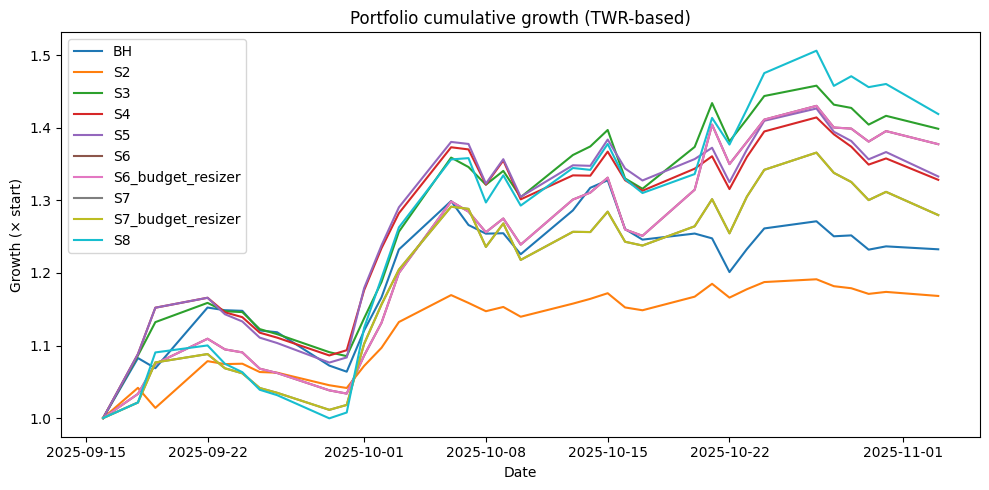

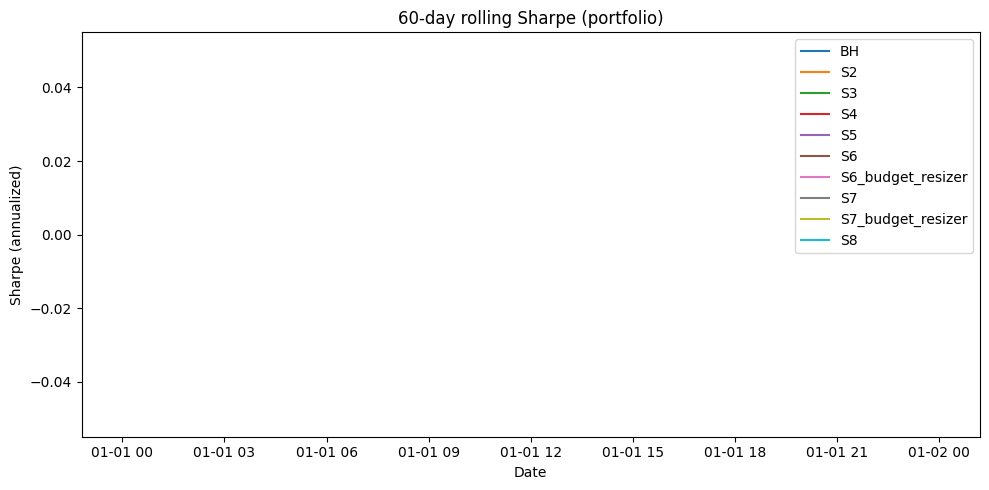

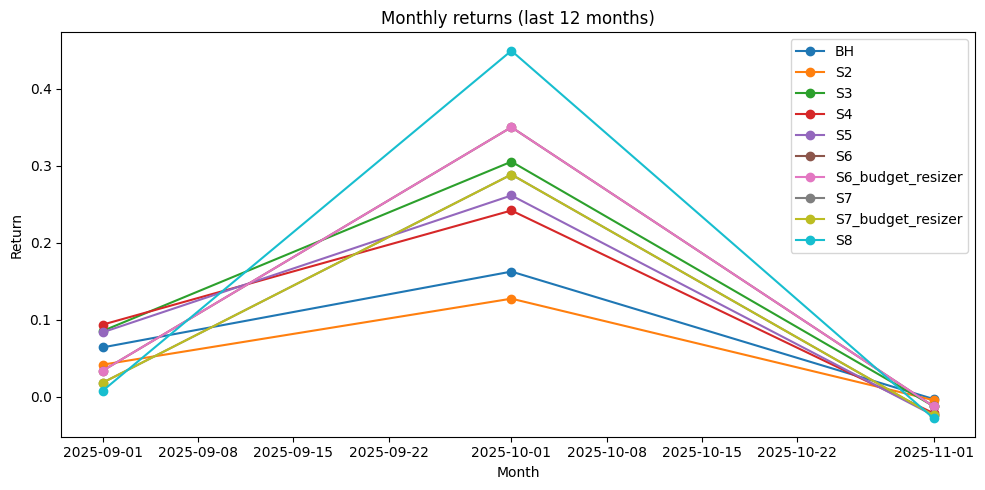

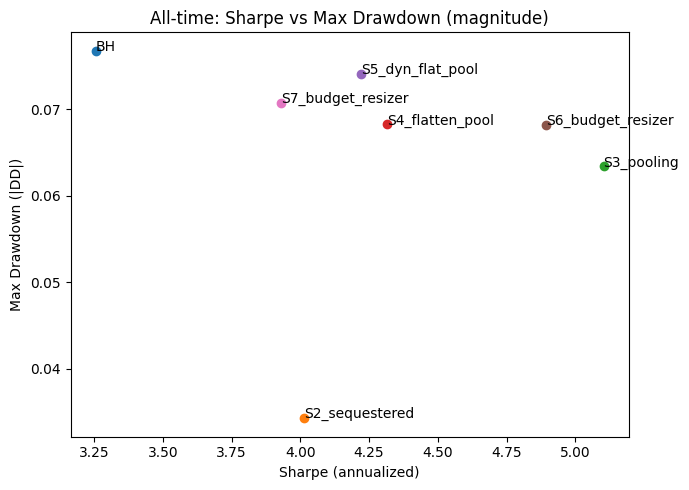

C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\2699538698.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=strategies, showmeans=True, meanline=True)


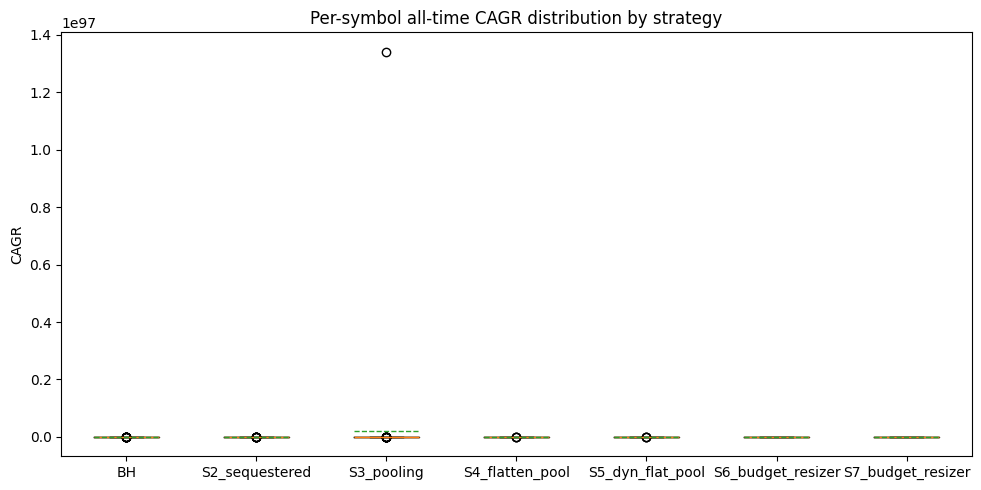

Plotted strategies: ['BH', 'S2', 'S3', 'S4', 'S5', 'S6', 'S6_budget_resizer', 'S7', 'S7_budget_resizer', 'S8']
✅ Charts saved to: C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\figs


In [389]:
# --- Cell V: Strategy visuals (inline + saved PNGs) ---

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

OUT  = Path("./out")
FIGS = OUT / "figs"
FIGS.mkdir(parents=True, exist_ok=True)

# ===== helpers =====
def ann_sharpe(daily_returns, trading_days=252):
    r = pd.Series(daily_returns).dropna()
    if r.empty: return np.nan
    mu = r.mean(); sd = r.std(ddof=1)
    if sd == 0: return np.nan
    return np.sqrt(trading_days) * (mu / sd)

def cagr_from_daily(daily_returns, trading_days=252):
    r = pd.Series(daily_returns).dropna()
    if r.empty: return np.nan
    growth = (1.0 + r).prod()
    n = len(r)
    if n == 0 or growth <= 0: return np.nan
    return growth ** (trading_days / n) - 1

def maxdd_from_returns(daily_returns):
    r = pd.Series(daily_returns).fillna(0.0)
    curve = (1.0 + r).cumprod()
    peak  = curve.cummax()
    dd    = (curve / peak) - 1.0
    return dd.min()

def month_compound(s):
    s = pd.Series(s).fillna(0.0)
    return (1.0 + s).prod() - 1.0

# ===== load data (prefer in-memory daily_all; else combine all on disk) =====
if "daily_all" in globals() and isinstance(daily_all, pd.DataFrame) and not daily_all.empty:
    port_daily = daily_all.copy()
else:
    dfs = []
    # pull every strat_daily_portfolio_*.csv so S8 and others appear automatically
    for fp in sorted(OUT.glob("strat_daily_portfolio_*.csv")):
        try:
            df = pd.read_csv(fp, parse_dates=["date"])
            if "strategy" not in df.columns:
                # infer from filename
                m = re.search(r"strat_daily_portfolio_(.+)\.csv$", fp.name, flags=re.I)
                tag = m.group(1) if m else "UNKNOWN"
                df.insert(0, "strategy", tag)
            # keep common columns
            keep = [c for c in ["strategy","date","equity","cash","invested","twr_ret"] if c in df.columns]
            dfs.append(df[keep])
        except Exception:
            pass
    if not dfs:
        # legacy single-file fallback
        daily_port_path = OUT / "strat_daily_portfolio.csv"
        if not daily_port_path.exists():
            raise FileNotFoundError("No strat_daily_portfolio_*.csv files found — run Cell L first.")
        df = pd.read_csv(daily_port_path, parse_dates=["date"])
        dfs.append(df)
    port_daily = pd.concat(dfs, ignore_index=True)

# normalize dtypes and sort
if "date" in port_daily.columns and not pd.api.types.is_datetime64_any_dtype(port_daily["date"]):
    port_daily["date"] = pd.to_datetime(port_daily["date"])
port_daily = port_daily.sort_values(["date","strategy"]).reset_index(drop=True)

# ensure twr_ret (derive from equity if missing)
if "twr_ret" not in port_daily.columns or port_daily["twr_ret"].isna().all():
    if "equity" not in port_daily.columns:
        raise ValueError("Need either 'twr_ret' or 'equity' to build visuals.")
    port_daily = port_daily.sort_values(["strategy","date"]).copy()
    port_daily["twr_ret"] = (
        port_daily
        .groupby("strategy", group_keys=False)["equity"]
        .apply(lambda s: pd.to_numeric(s, errors="coerce").astype(float).pct_change())
    )

# ===== optional all-time & per-symbol sources (fallbacks if not present) =====
port_alltime_path = OUT / "strat_alltime_portfolio.csv"
port_alltime = pd.read_csv(port_alltime_path) if port_alltime_path.exists() else None

ps_alltime_path = OUT / "strat_alltime_per_symbol.csv"
ps_alltime = pd.read_csv(ps_alltime_path) if ps_alltime_path.exists() else None

# ===== Plot 1: Portfolio cumulative growth (TWR-based) =====
plt.figure(figsize=(10,5))
for strat, g in port_daily.groupby("strategy"):
    g = g.sort_values("date")
    r = pd.to_numeric(g["twr_ret"], errors="coerce").fillna(0.0)
    cum = (1.0 + r).cumprod()
    plt.plot(g["date"], cum, label=strat)
plt.title("Portfolio cumulative growth (TWR-based)")
plt.xlabel("Date"); plt.ylabel("Growth (× start)")
plt.legend(); plt.tight_layout()
plt.savefig(FIGS / "portfolio_cumulative_growth.png", dpi=150)
plt.show()

# ===== Plot 2: 60-day rolling Sharpe =====
plt.figure(figsize=(10,5))
win = 60; ann = np.sqrt(252.0)
for strat, g in port_daily.groupby("strategy"):
    g = g.sort_values("date")
    r = pd.to_numeric(g["twr_ret"], errors="coerce").fillna(0.0)
    roll_mean = r.rolling(win).mean()
    roll_std  = r.rolling(win).std(ddof=1)
    roll_sharpe = (roll_mean / (roll_std + 1e-12)) * ann
    plt.plot(g["date"], roll_sharpe, label=strat)
plt.title("60-day rolling Sharpe (portfolio)")
plt.xlabel("Date"); plt.ylabel("Sharpe (annualized)")
plt.legend(); plt.tight_layout()
plt.savefig(FIGS / "portfolio_rolling_sharpe_60d.png", dpi=150)
plt.show()

# ===== Plot 3: Monthly returns (last 12 months) =====
plt.figure(figsize=(10,5))
dfm = port_daily.copy()
dfm["month"] = dfm["date"].dt.to_period("M")
monthly = (
    dfm.groupby(["strategy","month"])["twr_ret"]
       .apply(month_compound)
       .reset_index()
)
last_12 = monthly["month"].sort_values().unique()[-12:]
monthly12 = monthly[monthly["month"].isin(last_12)]
for strat, g in monthly12.groupby("strategy"):
    g = g.sort_values("month")
    x = g["month"].dt.to_timestamp()
    plt.plot(x, g["twr_ret"].values, marker="o", label=strat)
plt.title("Monthly returns (last 12 months)")
plt.xlabel("Month"); plt.ylabel("Return")
plt.legend(); plt.tight_layout()
plt.savefig(FIGS / "portfolio_monthly_returns_last12.png", dpi=150)
plt.show()

# ===== Plot 4: All-time Sharpe vs Max Drawdown =====
if port_alltime is None:
    # Compute from daily if the alltime CSV isn't there (works for S8 too)
    records = []
    for strat, g in port_daily.groupby("strategy"):
        g = g.sort_values("date")
        r = pd.to_numeric(g["twr_ret"], errors="coerce").fillna(0.0)
        records.append({
            "strategy": strat,
            "end_equity": (1.0 + r).cumprod().iloc[-1] if len(r) else np.nan,
            "sharpe": ann_sharpe(r),
            "cagr": cagr_from_daily(r),
            "maxdd": maxdd_from_returns(r),
            "days": len(r)
        })
    port_alltime = pd.DataFrame.from_records(records)

plt.figure(figsize=(7,5))
for _, row in port_alltime.iterrows():
    sh = pd.to_numeric(row.get("sharpe", np.nan), errors="coerce")
    md = pd.to_numeric(row.get("maxdd", np.nan), errors="coerce")
    if pd.notna(sh) and pd.notna(md):
        plt.scatter(sh, -md)
        if "strategy" in row:
            plt.annotate(str(row["strategy"]), (sh, -md))
plt.title("All-time: Sharpe vs Max Drawdown (magnitude)")
plt.xlabel("Sharpe (annualized)"); plt.ylabel("Max Drawdown (|DD|)")
plt.tight_layout()
plt.savefig(FIGS / "portfolio_sharpe_vs_maxdd.png", dpi=150)
plt.show()

# ===== Plot 5: Per-symbol all-time CAGR distribution by strategy =====
if ps_alltime is None:
    # Build from all per-symbol daily files if present
    ps_dfs = []
    for fp in sorted(OUT.glob("strat_daily_per_symbol_*.csv")):
        try:
            df = pd.read_csv(fp, parse_dates=["date"])
            if "strategy" not in df.columns:
                m = re.search(r"strat_daily_per_symbol_(.+)\.csv$", fp.name, flags=re.I)
                tag = m.group(1) if m else "UNKNOWN"
                df.insert(0, "strategy", tag)
            ps_dfs.append(df[["strategy","symbol","date","twr_ret"] if "twr_ret" in df.columns else "strategy symbol date twr_ret".split()])
        except Exception:
            pass
    if ps_dfs:
        ps_daily = pd.concat(ps_dfs, ignore_index=True)
    else:
        # Single legacy file fallback
        dps = OUT / "strat_daily_per_symbol.csv"
        ps_daily = pd.read_csv(dps, parse_dates=["date"]) if dps.exists() else None

    if ps_daily is not None and not ps_daily.empty:
        recs = []
        for (strategy, symbol), g in ps_daily.groupby(["strategy","symbol"]):
            r = pd.to_numeric(g.get("twr_ret", pd.Series(dtype=float)), errors="coerce").fillna(0.0)
            recs.append({"strategy": strategy, "symbol": symbol, "cagr": cagr_from_daily(r)})
        ps_alltime = pd.DataFrame.from_records(recs)

if ps_alltime is not None and not ps_alltime.empty:
    plt.figure(figsize=(10,5))
    strategies = sorted(ps_alltime["strategy"].dropna().unique().tolist()) if "strategy" in ps_alltime.columns else []
    box_data = [pd.to_numeric(ps_alltime.loc[ps_alltime["strategy"]==s, "cagr"], errors="coerce").dropna().values
                for s in strategies]
    if strategies and any(len(arr) > 0 for arr in box_data):
        plt.boxplot(box_data, labels=strategies, showmeans=True, meanline=True)
        plt.title("Per-symbol all-time CAGR distribution by strategy")
        plt.ylabel("CAGR")
        plt.tight_layout()
        plt.savefig(FIGS / "per_symbol_cagr_boxplot.png", dpi=150)
        plt.show()

print("Plotted strategies:", sorted(port_daily["strategy"].unique()))
print(f"✅ Charts saved to: {FIGS.resolve()}")


In [390]:
# --- Cell N: symbol-day overview (allocs, positions, realized %, pct of portfolio) ---

from pathlib import Path
import numpy as np
import pandas as pd
from collections import defaultdict

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

# === expects earlier in the notebook ===
# ev (date, symbol, side, pos_frac, price, optional: score)
# exec_buy_price(price), exec_sell_price(price), commission(notional), twr_daily_returns(equity_series, flow_series)
# per_symbol_daily (for S8 eligibility by prior-day cumulative realized)

# ---- Normalize the base event table ----
evN = ev[["date","symbol","side","pos_frac","price"]].copy()
evN["date"] = pd.to_datetime(evN["date"])
evN["side"] = evN["side"].astype(str).str.upper().fillna("HOLD")
evN["pos_frac"] = pd.to_numeric(evN["pos_frac"], errors="coerce").fillna(0.0)
evN = evN.dropna(subset=["date","symbol","price"]).sort_values(["date","symbol"])

pxN = evN.pivot(index="date", columns="symbol", values="price").sort_index()
datesN = pxN.index.tolist()
symsN  = pxN.columns.tolist()
first_date = evN.groupby("symbol")["date"].min()

def _twr_from_equity_and_flows(df_sym):
    eq = df_sym["equity"].astype(float).values
    fl = df_sym["flow"].astype(float).values
    r = []
    prev = None
    for i, e in enumerate(eq):
        f = fl[i]
        if prev is None or prev <= 0:
            r.append(np.nan)  # first obs has no prior
        else:
            r.append((e - prev - f) / prev)
        prev = e
    return pd.Series(r, index=df_sym.index)

# ---------- Strategy simulators (instrumented) ----------

def sim_BH_with_trades(ev, invest_per_symbol=200.0):
    px = ev.pivot(index="date", columns="symbol", values="price").sort_index()
    dates = px.index.tolist(); syms  = px.columns.tolist()
    first = ev.groupby("symbol")["date"].min().to_dict()

    shares = defaultdict(float)
    trades, states, ps_eq = [], [], []

    for dt in dates:
        for s in syms:
            p = px.loc[dt, s]
            if not pd.isna(p) and first.get(s) == dt:
                buy_px = exec_buy_price(p)
                qty = invest_per_symbol / max(buy_px, 1e-12)
                _ = commission(invest_per_symbol)
                shares[s] += qty
                trades.append({"date": dt, "symbol": s, "alloc_buy": invest_per_symbol, "alloc_sell": 0.0})

        for s in syms:
            p = px.loc[dt, s]
            if pd.isna(p):
                continue
            pos_val = shares[s] * float(p)
            states.append({"date": dt, "symbol": s, "pos_shares": shares[s], "pos_value": pos_val})
            ps_eq.append({
                "date": dt, "symbol": s,
                "equity": pos_val,
                "flow": invest_per_symbol if first.get(s) == dt else 0.0
            })

    ps = pd.DataFrame(ps_eq).sort_values(["symbol","date"]).reset_index(drop=True)
    ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(_twr_from_equity_and_flows).values

    trades = pd.DataFrame(trades).groupby(["date","symbol"], as_index=False).sum()
    states = pd.DataFrame(states).sort_values(["date","symbol"]).reset_index(drop=True)
    return trades, states, ps

def sim_S2_with_trades(ev, start_cash=100.0, start_invest=100.0):
    px = ev.pivot(index="date", columns="symbol", values="price").sort_index()
    dates = px.index.tolist(); syms  = px.columns.tolist()

    cash = defaultdict(float); shares = defaultdict(float); started = set()
    trades, states, ps_eq = [], [], []

    for dt in dates:
        day = ev[ev["date"]==dt]

        for s in syms:
            if s not in started and pd.notna(px.loc[dt, s]) and (day["symbol"]==s).any():
                started.add(s)
                cash[s] += start_cash
                p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                qty = start_invest / max(buy_px, 1e-12)
                _ = commission(start_invest)
                shares[s] += qty
                trades.append({"date": dt, "symbol": s, "alloc_buy": start_invest, "alloc_sell": 0.0})

        for _, r in day[day["side"]=="SELL"].iterrows():
            s, pf = r["symbol"], float(r["pos_frac"])
            if s in started and pd.notna(px.loc[dt, s]) and shares[s] > 0:
                p = px.loc[dt, s]; sell_px = exec_sell_price(p)
                pos_val = shares[s] * p
                qty = min(shares[s], (pf * pos_val) / max(sell_px, 1e-12))
                if qty > 0:
                    proceeds = qty * sell_px
                    fee = commission(proceeds)
                    shares[s] -= qty
                    cash[s] += (proceeds - fee)
                    trades.append({"date": dt, "symbol": s, "alloc_buy": 0.0, "alloc_sell": proceeds})

        for _, r in day[day["side"]=="BUY"].iterrows():
            s, pf = r["symbol"], float(r["pos_frac"])
            if s in started and pd.notna(px.loc[dt, s]) and cash[s] > 0:
                p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                use_cash = pf * cash[s]
                if use_cash > 0:
                    qty = use_cash / max(buy_px, 1e-12)
                    fee = commission(use_cash)
                    shares[s] += qty
                    cash[s] -= (use_cash + fee)
                    trades.append({"date": dt, "symbol": s, "alloc_buy": use_cash, "alloc_sell": 0.0})

        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                pv = shares[s]*px.loc[dt, s]
                states.append({"date": dt, "symbol": s, "pos_shares": shares[s], "pos_value": pv})
                ps_eq.append({"date": dt, "symbol": s, "equity": pv + cash[s],
                              "flow": (start_cash+start_invest) if first_date.get(s)==dt else 0.0})

    ps = pd.DataFrame(ps_eq).sort_values(["symbol","date"]).reset_index(drop=True)
    ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(_twr_from_equity_and_flows).values
    trades = pd.DataFrame(trades).groupby(["date","symbol"], as_index=False).sum()
    states = pd.DataFrame(states).sort_values(["date","symbol"]).reset_index(drop=True)
    return trades, states, ps

def sim_S3_like_with_trades(ev, flatten=False, dyn_weight=None,
                            start_cash=100.0, start_invest=100.0):
    px = ev.pivot(index="date", columns="symbol", values="price").sort_index()
    dates = px.index.tolist(); syms  = px.columns.tolist()

    shares = defaultdict(float); started = set(); pool_cash = 0.0
    trades, states, ps_eq, port_daily = [], [], [], []

    for dt in dates:
        day = ev[ev["date"]==dt]

        todays_syms = day["symbol"].unique()
        for s in todays_syms:
            if s not in started and pd.notna(px.loc[dt, s]):
                started.add(s)
                pool_cash += start_cash
                p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                qty = start_invest / max(buy_px, 1e-12)
                _ = commission(start_invest)
                shares[s] += qty
                trades.append({"date": dt, "symbol": s, "alloc_buy": start_invest, "alloc_sell": 0.0})

        for _, r in day[day["side"]=="SELL"].iterrows():
            s = r["symbol"]
            if s in started and pd.notna(px.loc[dt, s]) and shares[s] > 0:
                p = px.loc[dt, s]; sell_px = exec_sell_price(p)
                if flatten:
                    qty = shares[s]
                else:
                    pf = float(r["pos_frac"])
                    qty = min(shares[s], pf * shares[s])
                if qty > 0:
                    proceeds = qty * sell_px
                    fee = commission(proceeds)
                    shares[s] -= qty
                    if flatten:
                        shares[s] = 0.0
                    pool_cash += (proceeds - fee)
                    trades.append({"date": dt, "symbol": s, "alloc_buy": 0.0, "alloc_sell": proceeds})

        buys = day[day["side"]=="BUY"].copy()
        if not buys.empty and pool_cash > 0:
            if dyn_weight is not None:
                buys["_w"] = [
                    float(rr["pos_frac"]) * float(dyn_weight.get((dt, rr["symbol"]), 1.0))
                    for _, rr in buys.iterrows()
                ]
            else:
                buys["_w"] = pd.to_numeric(buys["pos_frac"], errors="coerce").fillna(0.0)

            wsum = buys["_w"].sum()
            pool_avail = float(pool_cash)
            if wsum > 0 and pool_avail > 0:
                plan = []
                for _, rr in buys.iterrows():
                    s, w = rr["symbol"], float(rr["_w"])
                    if w <= 0 or pd.isna(px.loc[dt, s]):
                        plan.append((s, 0.0)); continue
                    alloc = pool_avail * (w / wsum)
                    plan.append((s, alloc))
                total_cost = 0.0
                for s, alloc in plan:
                    if alloc <= 0: continue
                    p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                    qty = alloc / max(buy_px, 1e-12)
                    fee = commission(alloc)
                    shares[s] += qty
                    total_cost += (alloc + fee)
                    trades.append({"date": dt, "symbol": s, "alloc_buy": alloc, "alloc_sell": 0.0})
                pool_cash = max(0.0, pool_cash - total_cost)

        eq_total = pool_cash
        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                pv = shares[s]*px.loc[dt, s]
                states.append({"date": dt, "symbol": s, "pos_shares": shares[s], "pos_value": pv})
                ps_eq.append({"date": dt, "symbol": s, "equity": pv,
                              "flow": (start_cash+start_invest) if first_date.get(s)==dt else 0.0})
                eq_total += pv
        port_daily.append({"date": dt, "port_equity": eq_total, "pool_cash": pool_cash})

    ps = pd.DataFrame(ps_eq).sort_values(["symbol","date"]).reset_index(drop=True)
    if not ps.empty:
        ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(_twr_from_equity_and_flows).values
    trades = pd.DataFrame(trades).groupby(["date","symbol"], as_index=False).sum()
    states = pd.DataFrame(states).sort_values(["date","symbol"]).reset_index(drop=True)
    port_daily = pd.DataFrame(port_daily).sort_values("date").reset_index(drop=True)
    return trades, states, ps, port_daily

def sim_S6_with_trades(
    ev,
    start_cash=100.0,
    start_invest=100.0,
    acc_min_samples=10,
    min_frac=0.00,
    max_frac=0.50,
    weight_lo=0.5,
    weight_hi=1.5,
    flatten=False
):
    """S6: budgeted, evidence-weighted allocation (pool budget; HOLDs excluded from buys)."""
    df = ev[["date","symbol","side","pos_frac","price"]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df["side"] = df["side"].astype(str).str.upper().fillna("HOLD")
    df["pos_frac"] = pd.to_numeric(df["pos_frac"], errors="coerce").fillna(0.0)
    df = df.dropna(subset=["date","symbol","price"]).sort_values(["date","symbol"])

    df = df.sort_values(["symbol","date"])
    df["n_seen"] = df.groupby("symbol").cumcount()
    df = df.sort_values(["date","symbol"]).reset_index(drop=True)

    px = df.pivot(index="date", columns="symbol", values="price").sort_index()
    dates = px.index.tolist(); syms = px.columns.tolist()

    shares = defaultdict(float); started = set(); pool_cash = 0.0
    trades, states, ps_eq, port_daily = [], [], [], []

    if "score" in ev.columns:
        sc = ev[["date","symbol","score"]].assign(score=pd.to_numeric(ev["score"], errors="coerce")).dropna()
        score_map = sc.set_index(["date","symbol"])["score"].to_dict()
    else:
        score_map = {}

    for dt in dates:
        day = df[df["date"] == dt].copy()

        todays_syms = day["symbol"].unique()
        for s in todays_syms:
            if s not in started and pd.notna(px.loc[dt, s]):
                started.add(s)
                pool_cash += start_cash
                p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                qty = start_invest / max(buy_px, 1e-12)
                _ = commission(start_invest)
                shares[s] += qty
                trades.append({"date": dt, "symbol": s, "alloc_buy": start_invest, "alloc_sell": 0.0})

        for _, r in day[day["side"]=="SELL"].iterrows():
            s = r["symbol"]
            if s in started and pd.notna(px.loc[dt, s]) and shares[s] > 0:
                p = px.loc[dt, s]; sell_px = exec_sell_price(p)
                if flatten:
                    qty = shares[s]
                else:
                    pf = float(r["pos_frac"])
                    qty = min(shares[s], pf * shares[s])
                if qty > 0:
                    proceeds = qty * sell_px
                    fee = commission(proceeds)
                    shares[s] -= qty if not flatten else shares[s]
                    if flatten:
                        shares[s] = 0.0
                    pool_cash += (proceeds - fee)
                    trades.append({"date": dt, "symbol": s, "alloc_buy": 0.0, "alloc_sell": proceeds})

        buys = day[day["side"]=="BUY"].copy()
        if not buys.empty and pool_cash > 0:
            w = []
            for _, r in buys.iterrows():
                s = r["symbol"]
                base = float(r["pos_frac"])
                sc_val = score_map.get((dt, s), np.nan)
                if pd.notna(sc_val):
                    z = (sc_val - 0.5) / 0.4; z = max(-1.0, min(1.0, z))
                    sc_mult = 1.0 + 0.5 * z; sc_mult = np.clip(sc_mult, weight_lo, weight_hi)
                else:
                    sc_mult = 1.0
                n_seen = float(r.get("n_seen", 0.0))
                pen = min(1.0, n_seen / float(acc_min_samples)) if acc_min_samples > 0 else 1.0
                wi = base * sc_mult * pen
                wi = float(np.clip(wi, min_frac, max_frac)) if wi > 0 else 0.0
                w.append(wi)
            buys["_w"] = w
            wsum = buys["_w"].sum()

            if wsum > 0:
                budget = float(pool_cash)
                plan = []
                for _, rr in buys.iterrows():
                    s, wi = rr["symbol"], float(rr["_w"])
                    if wi <= 0 or pd.isna(px.loc[dt, s]):
                        plan.append((s, 0.0)); continue
                    alloc = budget * (wi / wsum)
                    plan.append((s, alloc))
                total_cost = 0.0
                for s, alloc in plan:
                    if alloc <= 0: continue
                    p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                    qty = alloc / max(buy_px, 1e-12)
                    fee = commission(alloc)
                    shares[s] += qty
                    total_cost += (alloc + fee)
                    trades.append({"date": dt, "symbol": s, "alloc_buy": alloc, "alloc_sell": 0.0})
                pool_cash = max(0.0, pool_cash - total_cost)

        eq_total = pool_cash
        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                pv = shares[s] * float(px.loc[dt, s])
                states.append({"date": dt, "symbol": s, "pos_shares": shares[s], "pos_value": pv})
                ps_eq.append({"date": dt, "symbol": s, "equity": pv, "flow": 0.0})
                eq_total += pv

        port_daily.append({"date": dt, "port_equity": eq_total, "pool_cash": pool_cash})

    ps = pd.DataFrame(ps_eq).sort_values(["symbol","date"]).reset_index(drop=True)
    if not ps.empty:
        ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(_twr_from_equity_and_flows).values
    trades = pd.DataFrame(trades).groupby(["date","symbol"], as_index=False).sum()
    states = pd.DataFrame(states).sort_values(["date","symbol"]).reset_index(drop=True)
    port_daily = pd.DataFrame(port_daily).sort_values("date").reset_index(drop=True)
    return trades, states, ps, port_daily

def sim_S7_with_trades(
    ev,
    start_cash=100.0, start_invest=100.0,
    acc_min_samples=10, min_frac=0.00, max_frac=0.50,
    weight_lo=0.5, weight_hi=1.5
):
    """S7: S6-style budget/evidence BUYs, but always FLATTENS on SELL."""
    df = ev[["date","symbol","side","pos_frac","price"]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df["side"] = df["side"].astype(str).str.upper().fillna("HOLD")
    df["pos_frac"] = pd.to_numeric(df["pos_frac"], errors="coerce").fillna(0.0)
    df = df.dropna(subset=["date","symbol","price"]).sort_values(["date","symbol"])

    df = df.sort_values(["symbol","date"])
    df["n_seen"] = df.groupby("symbol").cumcount()
    df = df.sort_values(["date","symbol"]).reset_index(drop=True)

    px = df.pivot(index="date", columns="symbol", values="price").sort_index()
    dates = px.index.tolist(); syms = px.columns.tolist()
    first = df.groupby("symbol")["date"].min().to_dict()

    shares = defaultdict(float); started = set(); pool_cash = 0.0
    trades, states, ps_eq, port_daily = [], [], [], []

    if "score" in ev.columns:
        sc = ev[["date","symbol","score"]].assign(score=pd.to_numeric(ev["score"], errors="coerce")).dropna()
        score_map = sc.set_index(["date","symbol"])["score"].to_dict()
    else:
        score_map = {}

    for dt in dates:
        day = df[df["date"]==dt].copy()

        todays_syms = day["symbol"].unique()
        for s in todays_syms:
            if s not in started and pd.notna(px.loc[dt, s]):
                started.add(s)
                pool_cash += start_cash
                p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                qty = start_invest / max(buy_px, 1e-12)
                _ = commission(start_invest)
                shares[s] += qty
                trades.append({"date": dt, "symbol": s, "alloc_buy": start_invest, "alloc_sell": 0.0})

        # SELL (FLATTEN)
        for _, r in day[day["side"]=="SELL"].iterrows():
            s = r["symbol"]
            if s in started and pd.notna(px.loc[dt, s]) and shares[s] > 0:
                p = px.loc[dt, s]; sell_px = exec_sell_price(p)
                qty = shares[s]
                proceeds = qty * sell_px
                fee = commission(proceeds)
                shares[s] = 0.0
                pool_cash += (proceeds - fee)
                trades.append({"date": dt, "symbol": s, "alloc_buy": 0.0, "alloc_sell": proceeds})

        # BUYs (exclude HOLD; evidence-weighted; normalize; spend pool once)
        buys = day[day["side"]=="BUY"].copy()
        if not buys.empty and pool_cash > 0:
            w = []
            for _, r in buys.iterrows():
                s = r["symbol"]; base = float(r["pos_frac"])
                sc_val = score_map.get((dt, s), np.nan)
                if pd.notna(sc_val):
                    z = (sc_val - 0.5) / 0.4; z = max(-1.0, min(1.0, z))
                    sc_mult = 1.0 + 0.5 * z; sc_mult = np.clip(sc_mult, weight_lo, weight_hi)
                else:
                    sc_mult = 1.0
                n_seen = float(r.get("n_seen", 0.0))
                pen = min(1.0, n_seen / float(acc_min_samples)) if acc_min_samples > 0 else 1.0
                wi = base * sc_mult * pen
                wi = float(np.clip(wi, min_frac, max_frac)) if wi > 0 else 0.0
                w.append(wi)
            buys["_w"] = w
            wsum = buys["_w"].sum()

            if wsum > 0:
                budget = float(pool_cash)
                plan, total_cost = [], 0.0
                for _, rr in buys.iterrows():
                    s, wi = rr["symbol"], float(rr["_w"])
                    if wi <= 0 or pd.isna(px.loc[dt, s]): 
                        plan.append((s, 0.0)); continue
                    alloc = budget * (wi / wsum)
                    plan.append((s, alloc))
                for s, alloc in plan:
                    if alloc <= 0: continue
                    p = px.loc[dt, s]; buy_px = exec_buy_price(p)
                    qty = alloc / max(buy_px, 1e-12)
                    fee = commission(alloc)
                    shares[s] += qty
                    total_cost += (alloc + fee)
                    trades.append({"date": dt, "symbol": s, "alloc_buy": alloc, "alloc_sell": 0.0})
                pool_cash = max(0.0, pool_cash - total_cost)

        eq_total = pool_cash
        for s in syms:
            if s in started and pd.notna(px.loc[dt, s]):
                pv = shares[s] * float(px.loc[dt, s])
                states.append({"date": dt, "symbol": s, "pos_shares": shares[s], "pos_value": pv})
                ps_eq.append({"date": dt, "symbol": s, "equity": pv, "flow": (start_cash + start_invest) if first.get(s)==dt else 0.0})
                eq_total += pv
        port_daily.append({"date": dt, "port_equity": eq_total, "pool_cash": pool_cash})

    ps = pd.DataFrame(ps_eq).sort_values(["symbol","date"]).reset_index(drop=True)
    if not ps.empty:
        ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(_twr_from_equity_and_flows).values
    trades = pd.DataFrame(trades).groupby(["date","symbol"], as_index=False).sum()
    states = pd.DataFrame(states).sort_values(["date","symbol"]).reset_index(drop=True)
    port_daily = pd.DataFrame(port_daily).sort_values("date").reset_index(drop=True)
    return trades, states, ps, port_daily

# ---------- Run instrumented sims ----------
bh_tr, bh_st, bh_ps = sim_BH_with_trades(evN, invest_per_symbol=200.0)
s2_tr, s2_st, s2_ps = sim_S2_with_trades(evN, start_cash=100.0, start_invest=100.0)
s3_tr, s3_st, s3_ps, s3_pd = sim_S3_like_with_trades(evN, flatten=False, dyn_weight=None)
s4_tr, s4_st, s4_ps, s4_pd = sim_S3_like_with_trades(evN, flatten=True,  dyn_weight=None)

# S5 dynamic weights from trailing accuracy (if available)
if "score" in ev.columns:
    dyn_w = (ev.set_index(["date","symbol"])["score"] - 0.5) / 0.4
    dyn_w = 1.0 + 0.5 * dyn_w.clip(-1.0, 1.0)  # [0.5..1.5]
else:
    dyn_w = None
s5_tr, s5_st, s5_ps, s5_pd = sim_S3_like_with_trades(evN, flatten=True, dyn_weight=dyn_w)

# S6: budget/evidence (fractional sells)
s6_tr, s6_st, s6_ps, s6_pd = sim_S6_with_trades(
    evN,
    start_cash=100.0, start_invest=100.0,
    acc_min_samples=10, min_frac=0.00, max_frac=0.50,
    weight_lo=0.5, weight_hi=1.5, flatten=False
)

# S7: budget/evidence (flatten sells)
s7_tr, s7_st, s7_ps, s7_pd = sim_S7_with_trades(
    evN,
    start_cash=100.0, start_invest=100.0,
    acc_min_samples=10, min_frac=0.00, max_frac=0.50,
    weight_lo=0.5, weight_hi=1.5
)

# S8: S5-like weighting but ONLY include symbols with PRIOR-DAY positive cumulative realized
assert 'per_symbol_daily' in globals(), "Missing per_symbol_daily for S8 eligibility."
m = per_symbol_daily.copy()
m["date"] = pd.to_datetime(m["date"])

# find cumulative realized column
REAL_CUM_CANDS = ['cum_realized','realized_cum','cum_realized_pct','cum_realized_return',
                  'cum_realized_pnl_pct','cum_realized_pnl','realized_pct_cum']
real_cum_col = next((c for c in REAL_CUM_CANDS if c in m.columns), None)
if real_cum_col is None:
    raise ValueError(f"Missing cumulative realized column; tried {REAL_CUM_CANDS}")

m = m.sort_values(["symbol","date"])
m["cum_realized_prev"] = m.groupby("symbol")[real_cum_col].shift(1)
elig = m[["date","symbol"]].assign(elig = m["cum_realized_prev"] > 0)

# build masked dynamic weights (Series indexed by (date,symbol))
eidx = evN.set_index(["date","symbol"]).index.drop_duplicates()
elig_map = elig.set_index(["date","symbol"])["elig"].reindex(eidx, fill_value=False)
if dyn_w is not None:
    base_w = dyn_w.reindex(eidx, fill_value=1.0)
else:
    base_w = pd.Series(1.0, index=eidx)

dyn_w8 = (base_w * elig_map.astype(float))

s8_tr, s8_st, s8_ps, s8_pd = sim_S3_like_with_trades(evN, flatten=True, dyn_weight=dyn_w8)

# ---------- Decision-day realized % (t -> t+1) ----------
def decision_day_realized(ps_df):
    df = ps_df.sort_values(["symbol","date"]).copy()
    df["realized_pct"] = df.groupby("symbol")["twr_ret"].shift(-1)
    return df[["date","symbol","realized_pct"]]

bh_rz = decision_day_realized(bh_ps).rename(columns={"realized_pct":"realized_pct_BH"})
s2_rz = decision_day_realized(s2_ps).rename(columns={"realized_pct":"realized_pct_S2"})
s3_rz = decision_day_realized(s3_ps).rename(columns={"realized_pct":"realized_pct_S3"})
s4_rz = decision_day_realized(s4_ps).rename(columns={"realized_pct":"realized_pct_S4"})
s5_rz = decision_day_realized(s5_ps).rename(columns={"realized_pct":"realized_pct_S5"})
s6_rz = decision_day_realized(s6_ps).rename(columns={"realized_pct":"realized_pct_S6"})
s7_rz = decision_day_realized(s7_ps).rename(columns={"realized_pct":"realized_pct_S7"})
s8_rz = decision_day_realized(s8_ps).rename(columns={"realized_pct":"realized_pct_S8"})

# ---------- Compose symbol-day overview ----------
base = evN[["date","symbol","side","pos_frac","price"]].copy()

def _merge_allocs(base, trades, states, prefix):
    df = base.merge(trades.rename(columns={
        "alloc_buy": f"alloc_buy_{prefix}",
        "alloc_sell": f"alloc_sell_{prefix}"
    }), on=["date","symbol"], how="left")
    df = df.merge(states.rename(columns={
        "pos_shares": f"pos_shares_{prefix}",
        "pos_value":  f"pos_value_{prefix}"
    }), on=["date","symbol"], how="left")
    return df

ov = base.copy()
ov = _merge_allocs(ov, bh_tr, bh_st, "BH")
ov = _merge_allocs(ov, s2_tr, s2_st, "S2")
ov = _merge_allocs(ov, s3_tr, s3_st, "S3")
ov = _merge_allocs(ov, s4_tr, s4_st, "S4")
ov = _merge_allocs(ov, s5_tr, s5_st, "S5")
ov = _merge_allocs(ov, s6_tr, s6_st, "S6")
ov = _merge_allocs(ov, s7_tr, s7_st, "S7")
ov = _merge_allocs(ov, s8_tr, s8_st, "S8")

# --- Merge portfolio equity (includes pool cash) for pooled strategies ---
ov = ov.merge(s3_pd.rename(columns={"port_equity":"port_equity_S3"})[["date","port_equity_S3"]], on="date", how="left")
ov = ov.merge(s5_pd.rename(columns={"port_equity":"port_equity_S5"})[["date","port_equity_S5"]], on="date", how="left")
ov = ov.merge(s6_pd.rename(columns={"port_equity":"port_equity_S6"})[["date","port_equity_S6"]], on="date", how="left")
ov = ov.merge(s7_pd.rename(columns={"port_equity":"port_equity_S7"})[["date","port_equity_S7"]], on="date", how="left")
ov = ov.merge(s8_pd.rename(columns={"port_equity":"port_equity_S8"})[["date","port_equity_S8"]], on="date", how="left")

# --- % of total portfolio equity per position (pooled strategies) ---
ov["pct_port_S3"] = np.where(ov["port_equity_S3"] > 0, ov["pos_value_S3"] / ov["port_equity_S3"], np.nan)
ov["pct_port_S5"] = np.where(ov["port_equity_S5"] > 0, ov["pos_value_S5"] / ov["port_equity_S5"], np.nan)
ov["pct_port_S6"] = np.where(ov["port_equity_S6"] > 0, ov["pos_value_S6"] / ov["port_equity_S6"], np.nan)
ov["pct_port_S7"] = np.where(ov["port_equity_S7"] > 0, ov["pos_value_S7"] / ov["port_equity_S7"], np.nan)
ov["pct_port_S8"] = np.where(ov["port_equity_S8"] > 0, ov["pos_value_S8"] / ov["port_equity_S8"], np.nan)

# --- Add realized % columns ---
for rz in [bh_rz, s2_rz, s3_rz, s4_rz, s5_rz, s6_rz, s7_rz, s8_rz]:
    ov = ov.merge(rz, on=["date","symbol"], how="left")

# Order columns
front = ["date","symbol","side","pos_frac","price"]
metrics = []
for tag in ["BH","S2","S3","S4","S5","S6","S7","S8"]:
    metrics += [f"alloc_buy_{tag}", f"alloc_sell_{tag}", f"pos_shares_{tag}", f"pos_value_{tag}"]
extra = [
    "port_equity_S3","pct_port_S3",
    "port_equity_S5","pct_port_S5",
    "port_equity_S6","pct_port_S6",
    "port_equity_S7","pct_port_S7",
    "port_equity_S8","pct_port_S8",
]
rcols = ["realized_pct_BH","realized_pct_S2","realized_pct_S3","realized_pct_S4",
         "realized_pct_S5","realized_pct_S6","realized_pct_S7","realized_pct_S8"]
cols = front + metrics + extra + rcols
ov = ov.reindex(columns=cols)

# Save & quick peek
out_path = OUT / "strat_symbol_day_overview.csv"
ov.to_csv(out_path, index=False)
print(f"✅ Wrote {len(ov):,} rows to {out_path.resolve()} (includes S8 + pct_port columns)")
display(ov.head(20))


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\619525819.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(_twr_from_equity_and_flows).values
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\619525819.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(_twr_from_equity_and_flows).values
C

✅ Wrote 1,230 rows to C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\strat_symbol_day_overview.csv (includes S8 + pct_port columns)


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\619525819.py:221: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ps["twr_ret"] = ps.groupby("symbol", group_keys=False).apply(_twr_from_equity_and_flows).values


,date,symbol,side,pos_frac,price,alloc_buy_BH,alloc_sell_BH,pos_shares_BH,pos_value_BH,alloc_buy_S2,...,port_equity_S8,pct_port_S8,realized_pct_BH,realized_pct_S2,realized_pct_S3,realized_pct_S4,realized_pct_S5,realized_pct_S6,realized_pct_S7,realized_pct_S8
0,2025-09-16,AI,BUY,0.3,17.3250,200.0,0.0,11.532479,199.800200,130.0,...,3797.202797,0.026309,0.042424,0.027426,0.170728,0.162702,0.162702,2.943536,3.454704,4.876488
1,2025-09-16,AMD,BUY,0.3,160.9600,200.0,0.0,1.241303,199.800200,130.0,...,3797.202797,0.026309,-0.015408,-0.010151,0.112896,0.104870,0.104870,2.885704,3.396872,-0.015408
2,2025-09-16,BYND,SELL,0.3,2.7665,200.0,0.0,72.221290,199.800200,100.0,...,3797.202797,0.000000,0.015724,0.005392,-0.288993,NaN,NaN,-0.288993,NaN,NaN
3,2025-09-16,CHGG,SELL,0.3,1.4800,200.0,0.0,135.000135,199.800200,100.0,...,3797.202797,0.000000,0.074324,0.025843,-0.355405,NaN,NaN,-0.355405,NaN,NaN
4,2025-09-16,GOOGL,SELL,0.3,251.9900,200.0,0.0,0.792889,199.800200,100.0,...,3797.202797,0.000000,-0.001310,-0.000598,-0.400786,NaN,NaN,-0.400786,NaN,NaN
5,2025-09-16,IBM,SELL,0.4,256.2600,200.0,0.0,0.779678,199.800200,100.0,...,3797.202797,0.000000,0.028448,0.008403,-0.382931,NaN,NaN,-0.382931,NaN,NaN
6,2025-09-16,IONQ,BUY,0.2,61.8684,200.0,0.0,3.229439,199.800200,120.0,...,3797.202797,0.026309,0.113088,0.067746,0.195638,0.192143,0.192143,1.563644,1.819228,2.530120
7,2025-09-16,LCID,SELL,0.4,19.9250,200.0,0.0,10.027614,199.800200,100.0,...,3797.202797,0.000000,0.049184,0.014615,-0.370489,NaN,NaN,-0.370489,NaN,NaN
8,2025-09-16,MSFT,BUY,0.4,510.5750,200.0,0.0,0.391324,199.800200,140.0,...,3797.202797,0.026309,-0.004515,-0.003219,0.047945,0.044013,0.044013,1.446041,1.701625,-0.004515
9,2025-09-16,NVDA,BUY,0.3,175.0450,200.0,0.0,1.141422,199.800200,130.0,...,3797.202797,0.026309,0.009797,0.006226,0.138101,0.130075,0.130075,2.910909,3.422077,4.843861


In [391]:
# --- Cell O: simplified symbol-day overview (signal + position sizing + pct_port) ---

from pathlib import Path
import pandas as pd

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)
SRC = OUT / "strat_symbol_day_overview.csv"  # produced by Cell N

# If the full overview isn't in memory, load it
if "ov" not in globals():
    if not SRC.exists():
        raise FileNotFoundError(f"Missing {SRC}. Run Cell N first.")
    ov = pd.read_csv(SRC, parse_dates=["date"])

# ----- detect which strategies are actually present -----
# Strategy tags inferred from pos_shares_* columns (e.g., pos_shares_S3 -> 'S3')
present_tags = sorted({
    col.split("_", 2)[-1] for col in ov.columns if col.startswith("pos_shares_")
})

# Keep a predictable order when possible (will drop ones not present, keep extras if any)
preferred_order = ["BH","S2","S3","S4","S5","S6","S7","S8"]
TAGS = [t for t in preferred_order if t in present_tags] + [t for t in present_tags if t not in preferred_order]

# ----- 1) Shares-only version -----
base_cols = ["date","symbol","side","pos_frac"]
share_cols = base_cols + [c for c in (f"pos_shares_{t}" for t in TAGS) if c in ov.columns]

ov_simple_shares = ov[share_cols].copy().sort_values(["date","symbol"]).reset_index(drop=True)
out_shares = OUT / "strat_symbol_day_overview_simple_shares.csv"
ov_simple_shares.to_csv(out_shares, index=False)

# ----- 2) Values-only version (include % of portfolio for pooled strategies) -----
value_cols = base_cols + [c for c in (f"pos_value_{t}" for t in TAGS) if c in ov.columns]

# Only include pct_port_* columns that exist (S3/S5/S6/S7/S8 are pooled)
pct_candidates = ["pct_port_S3","pct_port_S5","pct_port_S6","pct_port_S7","pct_port_S8"]
pct_cols = [c for c in pct_candidates if c in ov.columns]

ov_simple_values = ov[value_cols + pct_cols].copy().sort_values(["date","symbol"]).reset_index(drop=True)
out_values = OUT / "strat_symbol_day_overview_simple_values.csv"
ov_simple_values.to_csv(out_values, index=False)

print("✅ Wrote:")
print(" -", out_shares.resolve())
print(" -", out_values.resolve())
print("Included strategies:", TAGS)

# Quick previews
display(ov_simple_shares.head(12))
display(ov_simple_values.head(12))


✅ Wrote:
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\strat_symbol_day_overview_simple_shares.csv
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\strat_symbol_day_overview_simple_values.csv
Included strategies: ['BH', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']


,date,symbol,side,pos_frac,pos_shares_BH,pos_shares_S2,pos_shares_S3,pos_shares_S4,pos_shares_S5,pos_shares_S6,pos_shares_S7,pos_shares_S8
0,2025-09-16,AI,BUY,0.3,11.532479,7.496111,17.400208,20.434514,20.434514,5.766240,5.766240,5.766240
1,2025-09-16,AMD,BUY,0.3,1.241303,0.806847,1.872879,2.199478,2.199478,0.620652,0.620652,0.620652
2,2025-09-16,BYND,SELL,0.3,72.221290,25.266608,25.277452,0.000000,0.000000,25.277452,0.000000,0.000000
3,2025-09-16,CHGG,SELL,0.3,135.000135,47.229777,47.250047,0.000000,0.000000,47.250047,0.000000,0.000000
4,2025-09-16,GOOGL,SELL,0.3,0.792889,0.277392,0.277511,0.000000,0.000000,0.277511,0.000000,0.000000
5,2025-09-16,IBM,SELL,0.4,0.779678,0.233747,0.233903,0.000000,0.000000,0.233903,0.000000,0.000000
6,2025-09-16,IONQ,BUY,0.2,3.229439,1.937663,3.786625,4.353089,4.353089,1.614719,1.614719,1.614719
7,2025-09-16,LCID,SELL,0.4,10.027614,3.006277,3.008284,0.000000,0.000000,3.008284,0.000000,0.000000
8,2025-09-16,MSFT,BUY,0.4,0.391324,0.273927,0.722019,0.859300,0.859300,0.195662,0.195662,0.195662
9,2025-09-16,NVDA,BUY,0.3,1.141422,0.741924,1.722178,2.022497,2.022497,0.570711,0.570711,0.570711


,date,symbol,side,pos_frac,pos_value_BH,pos_value_S2,pos_value_S3,pos_value_S4,pos_value_S5,pos_value_S6,pos_value_S7,pos_value_S8,pct_port_S3,pct_port_S5,pct_port_S6,pct_port_S7,pct_port_S8
0,2025-09-16,AI,BUY,0.3,199.8002,129.87013,301.458600,354.027954,354.027954,99.90010,99.9001,99.9001,0.079424,0.093303,0.026305,0.026309,0.026309
1,2025-09-16,AMD,BUY,0.3,199.8002,129.87013,301.458600,354.027954,354.027954,99.90010,99.9001,99.9001,0.079424,0.093303,0.026305,0.026309,0.026309
2,2025-09-16,BYND,SELL,0.3,199.8002,69.90007,69.930070,0.000000,0.000000,69.93007,0.0000,0.0000,0.018424,0.000000,0.018413,0.000000,0.000000
3,2025-09-16,CHGG,SELL,0.3,199.8002,69.90007,69.930070,0.000000,0.000000,69.93007,0.0000,0.0000,0.018424,0.000000,0.018413,0.000000,0.000000
4,2025-09-16,GOOGL,SELL,0.3,199.8002,69.90007,69.930070,0.000000,0.000000,69.93007,0.0000,0.0000,0.018424,0.000000,0.018413,0.000000,0.000000
5,2025-09-16,IBM,SELL,0.4,199.8002,59.90006,59.940060,0.000000,0.000000,59.94006,0.0000,0.0000,0.015792,0.000000,0.015783,0.000000,0.000000
6,2025-09-16,IONQ,BUY,0.2,199.8002,119.88012,234.272433,269.318669,269.318669,99.90010,99.9001,99.9001,0.061723,0.070978,0.026305,0.026309,0.026309
7,2025-09-16,LCID,SELL,0.4,199.8002,59.90006,59.940060,0.000000,0.000000,59.94006,0.0000,0.0000,0.015792,0.000000,0.015783,0.000000,0.000000
8,2025-09-16,MSFT,BUY,0.4,199.8002,139.86014,368.644766,438.737238,438.737238,99.90010,99.9001,99.9001,0.097125,0.115627,0.026305,0.026309,0.026309
9,2025-09-16,NVDA,BUY,0.3,199.8002,129.87013,301.458600,354.027954,354.027954,99.90010,99.9001,99.9001,0.079424,0.093303,0.026305,0.026309,0.026309


In [392]:
# --- Cell O2: add % of total portfolio equity for S3/S5/S6/S7/S8 using existing outputs ---

from pathlib import Path
import numpy as np
import pandas as pd

OUT = Path("./out")

# Load overview if needed
if "ov" not in globals():
    src = OUT / "strat_symbol_day_overview.csv"
    if not src.exists():
        raise FileNotFoundError("Missing strat_symbol_day_overview.csv — run Cell N first.")
    ov = pd.read_csv(src, parse_dates=["date"])

ov = ov.copy()

# Tags we can compute for (pooled strategies have port_equity_* & pos_value_*)
POOLED_TAGS = ["S3", "S5", "S6", "S7", "S8"]

# Ensure numeric for pos_value_* and port_equity_* if present
for tag in POOLED_TAGS:
    pv = f"pos_value_{tag}"
    pe = f"port_equity_{tag}"
    if pv in ov.columns:
        ov[pv] = pd.to_numeric(ov[pv], errors="coerce")
    if pe in ov.columns:
        ov[pe] = pd.to_numeric(ov[pe], errors="coerce")

# Compute % of portfolio for each available tag (percent, not fraction)
for tag in POOLED_TAGS:
    pv = f"pos_value_{tag}"
    pe = f"port_equity_{tag}"
    pct = f"pct_port_{tag}"
    if pv in ov.columns and pe in ov.columns:
        ov[pct] = np.where(ov[pe] > 0.0, (ov[pv] / ov[pe]) * 100.0, np.nan)

# Update the simplified “values” CSV to include the percents that exist
base_cols = ["date","symbol","side","pos_frac"]

# include all pos_value_* that exist (BH/S2/S3/S4/S5/S6/S7/S8 etc.)
pos_value_cols = [c for c in ov.columns if c.startswith("pos_value_")]

# include only pct_port_* columns that exist
pct_cols = [c for c in ov.columns if c.startswith("pct_port_")]

value_cols = base_cols + sorted(pct_cols) + sorted(pos_value_cols)

ov_simple_values_pct = (
    ov[value_cols]
    .sort_values(["date","symbol"])
    .reset_index(drop=True)
)

out_values = OUT / "strat_symbol_day_overview_simple_values.csv"
ov_simple_values_pct.to_csv(out_values, index=False)

print("✅ Updated simplified values with pct_port_* (percent units) for available pooled strategies.")
print("Included pct columns:", sorted(pct_cols))
print("→", out_values.resolve())

# Quick preview
display(ov_simple_values_pct.head(12))


✅ Updated simplified values with pct_port_* (percent units) for available pooled strategies.
Included pct columns: ['pct_port_S3', 'pct_port_S5', 'pct_port_S6', 'pct_port_S7', 'pct_port_S8']
→ C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\strat_symbol_day_overview_simple_values.csv


,date,symbol,side,pos_frac,pct_port_S3,pct_port_S5,pct_port_S6,pct_port_S7,pct_port_S8,pos_value_BH,pos_value_S2,pos_value_S3,pos_value_S4,pos_value_S5,pos_value_S6,pos_value_S7,pos_value_S8
0,2025-09-16,AI,BUY,0.3,7.942390,9.330257,2.630485,2.630887,2.630887,199.8002,129.87013,301.458600,354.027954,354.027954,99.90010,99.9001,99.9001
1,2025-09-16,AMD,BUY,0.3,7.942390,9.330257,2.630485,2.630887,2.630887,199.8002,129.87013,301.458600,354.027954,354.027954,99.90010,99.9001,99.9001
2,2025-09-16,BYND,SELL,0.3,1.842415,0.000000,1.841340,0.000000,0.000000,199.8002,69.90007,69.930070,0.000000,0.000000,69.93007,0.0000,0.0000
3,2025-09-16,CHGG,SELL,0.3,1.842415,0.000000,1.841340,0.000000,0.000000,199.8002,69.90007,69.930070,0.000000,0.000000,69.93007,0.0000,0.0000
4,2025-09-16,GOOGL,SELL,0.3,1.842415,0.000000,1.841340,0.000000,0.000000,199.8002,69.90007,69.930070,0.000000,0.000000,69.93007,0.0000,0.0000
5,2025-09-16,IBM,SELL,0.4,1.579213,0.000000,1.578291,0.000000,0.000000,199.8002,59.90006,59.940060,0.000000,0.000000,59.94006,0.0000,0.0000
6,2025-09-16,IONQ,BUY,0.2,6.172268,7.097779,2.630485,2.630887,2.630887,199.8002,119.88012,234.272433,269.318669,269.318669,99.90010,99.9001,99.9001
7,2025-09-16,LCID,SELL,0.4,1.579213,0.000000,1.578291,0.000000,0.000000,199.8002,59.90006,59.940060,0.000000,0.000000,59.94006,0.0000,0.0000
8,2025-09-16,MSFT,BUY,0.4,9.712513,11.562734,2.630485,2.630887,2.630887,199.8002,139.86014,368.644766,438.737238,438.737238,99.90010,99.9001,99.9001
9,2025-09-16,NVDA,BUY,0.3,7.942390,9.330257,2.630485,2.630887,2.630887,199.8002,129.87013,301.458600,354.027954,354.027954,99.90010,99.9001,99.9001


In [393]:
# --- Quick views of day-by-day realized % ---

# 1) Raw realized % per symbol per day (all strategies)
rz_cols = ["date","symbol"] + [c for c in ov.columns if c.startswith("realized_pct_")]
display(ov[rz_cols].sort_values(["date","symbol"]).tail(40))

# 2) Only on BUY decision days (often the most interesting)
buy_cols = ["date","symbol","side"] + [c for c in ov.columns if c.startswith("realized_pct_")]
display(ov.loc[ov["side"].eq("BUY"), buy_cols].sort_values(["date","symbol"]).tail(40))

# 3) Daily average realized % across symbols (BUY-only), by strategy
daily_mean = (
    ov.loc[ov["side"].eq("BUY"), ["date"] + [c for c in ov.columns if c.startswith("realized_pct_")]]
      .groupby("date").mean(numeric_only=True)
      .rename(columns=lambda c: c.replace("realized_pct_","mean_"))
      .reset_index()
)
display(daily_mean.tail(15))

,date,symbol,realized_pct_BH,realized_pct_S2,realized_pct_S3,realized_pct_S4,realized_pct_S5,realized_pct_S6,realized_pct_S7,realized_pct_S8
1190,2025-11-03,IBM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1191,2025-11-03,INFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1192,2025-11-03,INTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1193,2025-11-03,IONQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1194,2025-11-03,ITRI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1195,2025-11-03,LCID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1196,2025-11-03,MDB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1197,2025-11-03,MNTK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1198,2025-11-03,MRK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1199,2025-11-03,MSFT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,date,symbol,side,realized_pct_BH,realized_pct_S2,realized_pct_S3,realized_pct_S4,realized_pct_S5,realized_pct_S6,realized_pct_S7,realized_pct_S8
1112,2025-10-31,ARQQ,BUY,-0.079776,-0.061713,-0.355843,-1.000000,-1.000000,-0.355843,-1.000000,-1.000000
1114,2025-10-31,BHP,BUY,-0.017547,-0.007332,-0.410528,-1.000000,-1.000000,-0.410528,-1.000000,NaN
1116,2025-10-31,CHGG,BUY,-0.091133,-0.066300,0.057556,0.086258,0.047818,0.038073,0.056102,NaN
1121,2025-10-31,ENVX,BUY,0.040103,0.008614,-0.375938,-1.000000,-1.000000,-0.375938,-1.000000,-1.000000
1127,2025-10-31,GOOGL,BUY,0.009766,0.007374,0.056131,0.209742,0.145489,0.045085,0.178835,0.009766
1133,2025-10-31,LCID,BUY,-0.061408,-0.037924,-0.061408,-0.061408,-0.061408,-0.061408,-0.061408,-0.061408
1137,2025-10-31,MSFT,BUY,0.006057,0.003002,-0.195155,-1.000000,-1.000000,-0.195155,-1.000000,-1.000000
1140,2025-10-31,NFLX,BUY,-0.030367,-0.017431,-0.418220,-1.000000,-1.000000,-0.418220,-1.000000,NaN
1142,2025-10-31,NVTS,BUY,-0.054348,-0.034130,-0.243478,-1.000000,-1.000000,-0.243478,-1.000000,NaN
1145,2025-10-31,PG,BUY,-0.013253,-0.004141,0.808588,1.715724,2.170174,0.889563,1.716073,NaN


,date,mean_BH,mean_S2,mean_S3,mean_S4,mean_S5,mean_S6,mean_S7,mean_S8
19,2025-10-14,0.024328,0.017404,0.153836,1.757648e-01,0.198589,0.136572,0.127471,0.725971
20,2025-10-15,-0.035565,-0.020451,-0.112977,-3.879594e-01,-0.398061,-0.123688,-0.388031,-0.310632
21,2025-10-16,-0.012650,-0.010774,0.245339,-1.265004e-02,-0.012650,0.301320,-0.012650,-0.014462
22,2025-10-17,0.146292,0.072533,0.408512,4.232526e+14,-0.090965,0.578716,0.053100,0.099017
23,2025-10-20,0.034954,0.031379,0.149670,1.902414e-01,0.188071,0.149298,0.284418,0.273219
24,2025-10-21,-0.044297,-0.030328,0.004145,-1.071139e-01,-0.113561,-0.000204,-0.136111,-0.238126
25,2025-10-22,0.037534,0.025416,0.098496,-4.919710e-02,-0.014650,0.119965,-0.004936,-0.294242
26,2025-10-23,0.029361,0.023714,0.151076,9.866213e-02,0.110484,0.203705,0.329348,0.161235
27,2025-10-24,0.015580,0.013198,0.099363,4.504542e-01,0.508971,0.160368,0.480095,1.169452
28,2025-10-27,-0.023316,-0.014725,-0.026162,-2.025490e-01,-0.176486,-0.032238,-0.218122,-0.276507


In [394]:
# --- Cell W (updated): Weekly-hold vs daily-trading comparison (per strategy) ---
"""
Compares a Friday→next-Friday "weekly-hold" (freeze positions at Friday close, hold a week)
against the actual daily-trading TWR over the same window, for each strategy.
Outputs: ./out/weekly_hold_vs_daily.csv and a compact pivot preview.
"""

from pathlib import Path
import pandas as pd
import numpy as np
import re

OUT = Path("./out")

# ---- Load artifacts we already produced ----
# Full symbol-day overview (positions by strategy per day)
if "ov" not in globals():
    ov_path = OUT / "strat_symbol_day_overview.csv"
    if not ov_path.exists():
        raise FileNotFoundError("Missing strat_symbol_day_overview.csv (run Cell N).")
    ov = pd.read_csv(ov_path, parse_dates=["date"])

# Portfolio daily (equity & TWR per strategy)
if "port_daily_all" not in globals():
    p = OUT / "strat_daily_portfolio.csv"
    if not p.exists():
        raise FileNotFoundError("Missing strat_daily_portfolio.csv (run Cell L/N).")
    port_daily_all = pd.read_csv(p, parse_dates=["date"])

# Per-symbol daily (for S2 cash reconstruction)
ps_daily_path = OUT / "strat_daily_per_symbol.csv"
ps_daily = pd.read_csv(ps_daily_path, parse_dates=["date"]) if ps_daily_path.exists() else None

# Build price panel from OV (date,symbol,price)
px = (ov[["date","symbol","price"]]
      .dropna()
      .drop_duplicates()
      .pivot(index="date", columns="symbol", values="price")
      .sort_index())

# ---- Detect strategies present (OV + daily) ----
have_names = set(port_daily_all["strategy"].astype(str).unique())

def pick_name(tag: str) -> str | None:
    # 1) friendly aliases
    aliases = {
        "BH": ["BH","BuyHold","Buy_and_Hold"],
        "S2": ["S2_sequestered","S2"],
        "S3": ["S3_pooling","S3"],
        "S4": ["S4_flatten_pool","S4"],
        "S5": ["S5_weighted","S5_dyn_flat_pool","S5"],
        "S8": ["S8_pos_realized","S8_only_winners","S8"],
    }.get(tag, [])
    for cand in aliases:
        if cand in have_names:
            return cand
    # 2) fuzzy: contains the tag string (case-insensitive), e.g., any name with "S8"
    rx = re.compile(rf"(^|[^A-Za-z0-9]){re.escape(tag)}([^A-Za-z0-9]|$)", re.I)
    for n in have_names:
        if rx.search(n):
            return n
    return None

# Which tags can we evaluate? Need OV columns for positions; name used only for daily TWR.
candidate_tags = ["BH","S2","S3","S4","S5","S8"]
need_cols = lambda t: [f"pos_shares_{t}", f"pos_value_{t}"]
tags_ov = [t for t in candidate_tags if all(c in ov.columns for c in need_cols(t))]
STRATS = {t: pick_name(t) for t in tags_ov}  # may be None if daily name not found

# Helper: compound daily TWR between (t0, t1] from portfolio daily (requires a name)
def compounded_twr(pdaily, strat_name, t0, t1):
    if not strat_name:
        return np.nan
    g = pd.DataFrame(pdaily[(pdaily["strategy"]==strat_name) & (pdaily["date"]>t0) & (pdaily["date"]<=t1)])
    if g.empty:
        return np.nan
    r = pd.to_numeric(g["twr_ret"], errors="coerce").fillna(0.0)
    return (1.0 + r).prod() - 1.0

# Identify Fridays and next Fridays in our trading calendar
dates_all = px.index.sort_values()
fridays = dates_all[dates_all.weekday == 4]  # Friday
friday_pairs = [(fridays[i], fridays[i+1]) for i in range(len(fridays)-1)]

# For S2, per-symbol cash at EOD Friday: cash = (per-symbol equity) - (pos_value from OV)
def per_symbol_cash_S2_on(dateF):
    if ps_daily is None or "strategy" not in ps_daily.columns:
        return {}
    s2_name = STRATS.get("S2")
    if not s2_name:
        return {}
    df_eq = ps_daily[(ps_daily["strategy"]==s2_name) & (ps_daily["date"]==dateF)][["symbol","equity"]]
    df_pos = ov[(ov["date"]==dateF)][["symbol","pos_value_S2"]]
    tmp = df_eq.merge(df_pos, on="symbol", how="left")
    tmp["equity"] = pd.to_numeric(tmp["equity"], errors="coerce")
    tmp["pos_value_S2"] = pd.to_numeric(tmp["pos_value_S2"], errors="coerce").fillna(0.0)
    tmp["cash"] = tmp["equity"] - tmp["pos_value_S2"]
    return dict(zip(tmp["symbol"], tmp["cash"].fillna(0.0)))

# Compute weekly-hold return given Friday F -> next Friday N for a strategy tag
def weekly_hold_return(tag, F, N):
    shares_col = f"pos_shares_{tag}"
    val_col    = f"pos_value_{tag}"

    snap = ov[ov["date"]==F][["symbol", shares_col, val_col]].copy()
    if snap.empty or shares_col not in snap.columns:
        return np.nan, np.nan, np.nan  # start, end, return

    # Constant shares across the week
    snap[shares_col] = pd.to_numeric(snap[shares_col], errors="coerce").fillna(0.0)

    # Cash terms at Friday close
    pool_cash = 0.0
    per_sym_cash = {}

    # Prefer exact pool equity from OV if present (decouples from daily file naming)
    port_eq_col = f"port_equity_{tag}"
    if port_eq_col in ov.columns and tag in ("S3","S4","S5","S8"):
        eqF = pd.to_numeric(ov.loc[ov["date"]==F, port_eq_col], errors="coerce").dropna()
        eqF = float(eqF.iloc[0]) if len(eqF) else np.nan
        pos_sumF = pd.to_numeric(snap[val_col], errors="coerce").fillna(0.0).sum()
        pool_cash = max(0.0, (eqF - pos_sumF)) if pd.notna(eqF) else 0.0
    elif tag in ("S3","S4","S5","S8"):
        # Fallback: reconstruct from daily file if needed
        strat_name = STRATS.get(tag)
        eqF = port_daily_all.loc[
            (port_daily_all["strategy"]==strat_name) & (port_daily_all["date"]==F), "equity"
        ]
        eqF = float(eqF.iloc[0]) if len(eqF) else np.nan
        pos_sumF = pd.to_numeric(snap[val_col], errors="coerce").fillna(0.0).sum()
        pool_cash = max(0.0, (eqF - pos_sumF)) if pd.notna(eqF) else 0.0
    elif tag=="S2":
        per_sym_cash = per_symbol_cash_S2_on(F)

    # Build equity path from (F, N] with constant shares (and constant cash/pool)
    span_dates = dates_all[(dates_all>F) & (dates_all<=N)]
    if len(span_dates)==0:
        return np.nan, np.nan, np.nan

    col_syms = snap["symbol"].tolist()
    sh = pd.to_numeric(snap[shares_col], errors="coerce").to_numpy()

    def equity_on(d):
        pr = pd.to_numeric(px.loc[d, col_syms], errors="coerce").to_numpy()
        pos_val = float(np.nansum(sh * pr))
        if tag in ("S3","S4","S5","S8"):
            return pos_val + pool_cash
        elif tag == "S2":
            cash_total = float(np.nansum([per_sym_cash.get(sym, 0.0) for sym in col_syms])) if per_sym_cash else 0.0
            return pos_val + cash_total
        else:  # BH
            return pos_val

    E0 = equity_on(F)   # Friday close (after trades)
    E1 = equity_on(N)   # next Friday close
    ret = (E1 / E0 - 1.0) if (pd.notna(E0) and E0>0 and pd.notna(E1)) else np.nan
    return E0, E1, ret

# Assemble comparison table
rows = []
for F, N in friday_pairs:
    for tag in STRATS:  # tag may map to None daily name; we still compute hold_ret
        strat_name = STRATS[tag]
        E0, E1, hold_ret = weekly_hold_return(tag, F, N)
        daily_ret = compounded_twr(port_daily_all, strat_name, F, N)  # may be NaN if name not found
        rows.append({
            "week_start": F, "week_end": N, "strategy": strat_name or tag,
            "hold_start_equity": E0, "hold_end_equity": E1,
            "ret_weekly_hold": hold_ret,
            "ret_daily_compounded": daily_ret,
            "diff_hold_minus_daily": (hold_ret - daily_ret) if pd.notna(hold_ret) and pd.notna(daily_ret) else np.nan
        })

weekly_cmp = pd.DataFrame(rows).sort_values(["week_start","strategy"]).reset_index(drop=True)

# Save & small side-by-side pivot
out_path = OUT / "weekly_hold_vs_daily.csv"
weekly_cmp.to_csv(out_path, index=False)

print(f"✅ Wrote weekly comparison to {out_path.resolve()}")
print("Included tags:", list(STRATS.keys()))
print("Name mapping:", STRATS)

# Show last ~8 weeks as a compact pivot
pivot = weekly_cmp.copy()
pivot["week"] = pivot["week_start"].dt.strftime("%Y-%m-%d")
view = pivot.pivot(index="week", columns="strategy", values="diff_hold_minus_daily").tail(8)
print("\nΔ (Hold − Daily) return by week (last 8):")
try:
    display(view)
except NameError:
    print(view)

# Full table peek
try:
    display(weekly_cmp.tail(15))
except NameError:
    print(weekly_cmp.tail(15))


✅ Wrote weekly comparison to C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\weekly_hold_vs_daily.csv
Included tags: ['BH', 'S2', 'S3', 'S4', 'S5', 'S8']
Name mapping: {'BH': 'BH', 'S2': 'S2', 'S3': 'S3', 'S4': 'S4', 'S5': 'S5', 'S8': 'S8'}

Δ (Hold − Daily) return by week (last 8):


strategy,BH,S2,S3,S4,S5,S8
week,,,,,,
2025-09-19,-4.901302e-02,-0.066867,-0.012365,-0.005162,0.001282,-0.001574
2025-09-26,1.522223e-02,0.030947,-0.027320,-0.055097,-0.068657,-0.106301
2025-10-03,-6.661338e-16,0.014006,0.020659,0.038126,0.037601,0.038621
2025-10-10,-2.145690e-02,-0.030392,-0.025778,-0.019867,-0.026587,-0.029373
2025-10-17,4.298261e-03,0.058323,-0.017527,-0.036100,-0.039103,-0.115982
2025-10-24,0.000000e+00,-0.014938,0.007463,0.029201,0.033996,0.042123


,week_start,week_end,strategy,hold_start_equity,hold_end_equity,ret_weekly_hold,ret_daily_compounded,diff_hold_minus_daily
21,2025-10-10,2025-10-17,S4,5993.056877,5928.662832,-0.010745,0.009122,-0.019867
22,2025-10-10,2025-10-17,S5,6000.762412,5944.866123,-0.009315,0.017272,-0.026587
23,2025-10-10,2025-10-17,S8,6010.831765,5914.722504,-0.015989,0.013384,-0.029373
24,2025-10-17,2025-10-24,BH,8257.097346,8395.015708,0.016703,0.012405,0.004298
25,2025-10-17,2025-10-24,S2,2613.783253,2854.715054,0.092177,0.033854,0.058323
26,2025-10-17,2025-10-24,S3,8592.991404,9277.557681,0.079666,0.097193,-0.017527
27,2025-10-17,2025-10-24,S4,8607.266753,8832.005045,0.026110,0.062210,-0.036100
28,2025-10-17,2025-10-24,S5,8648.293104,8846.305648,0.022896,0.061999,-0.039103
29,2025-10-17,2025-10-24,S8,8611.596543,8699.507067,0.010208,0.126190,-0.115982
30,2025-10-24,2025-10-31,BH,13387.663690,13125.371644,-0.019592,-0.019592,0.000000


In [395]:
to_peek = [
    "port_daily_all", "weekly", "monthly", "yearly", "alltime",
    "ps_all", "sym_roll",
    "bh_port", "s2_port", "s3_port", "s4_port", "s5_port",
    "bh_per_sym", "s2_ps", "s3_ps", "s4_ps", "s5_ps",
    "bh_roll", "s2_roll", "s3_roll", "s4_roll", "s5_roll",
    "ev", "dyn_w"
]

for name in to_peek:
    obj = globals().get(name, None)
    if obj is None:
        print(f"{name}: (not defined)")
        continue
    print(f"\n=== {name} ===")
    if hasattr(obj, "head"):  # DataFrame-like
        try:
            display(obj.head(5))
        except Exception:
            print(type(obj))
    else:
        print(type(obj))
        try:
            print(str(obj)[:500], "...")
        except Exception:
            pass



=== port_daily_all ===


,strategy,date,twr_ret,equity,flow
238,BH,2025-09-16,0.000000,3796.203796,3800.0
239,BH,2025-09-18,0.082692,4110.119239,0.0
240,BH,2025-09-19,-0.012936,4056.950056,0.0
241,BH,2025-09-22,0.078266,4374.470113,0.0
242,BH,2025-09-23,-0.003190,4360.517406,0.0



=== weekly ===


,week,days,sharpe,cagr,maxdd,end_equity,xirr,strategy,level
0,2025-09-16/2025-09-22,4.0,11.630629,7572.277629,-0.012936,4374.470113,NaN,BH,portfolio
1,2025-09-23/2025-09-29,5.0,-12.671312,-0.973440,-0.066483,4070.615095,NaN,BH,portfolio
2,2025-09-30/2025-10-06,5.0,23.083672,15895.833187,0.000000,6045.801396,NaN,BH,portfolio
3,2025-10-07/2025-10-13,5.0,-0.852416,-0.395032,-0.031840,5985.813400,NaN,BH,portfolio
4,2025-10-14/2025-10-20,5.0,-2.593390,-0.718350,-0.061661,13312.741874,1.254347e+14,BH,portfolio



=== monthly ===


...

,date,symbol,equity,flow,twr_ret
0,2025-10-20,AAPL,0.000000,200.0,NaN
1,2025-10-21,AAPL,0.000000,0.0,NaN
2,2025-10-22,AAPL,0.000000,0.0,NaN
3,2025-10-23,AAPL,88.766331,0.0,NaN
4,2025-10-24,AAPL,0.000000,0.0,-1.0



=== bh_roll ===
<class 'dict'>
{'weekly':                     week  days     sharpe          cagr     maxdd  \
0  2025-09-16/2025-09-22   4.0  11.630629   7572.277629 -0.012936   
1  2025-09-23/2025-09-29   5.0 -12.671312     -0.973440 -0.066483   
2  2025-09-30/2025-10-06   5.0  23.083672  15895.833187  0.000000   
3  2025-10-07/2025-10-13   5.0  -0.852416     -0.395032 -0.031840   
4  2025-10-14/2025-10-20   5.0  -2.593390     -0.718350 -0.061661   
5  2025-10-21/2025-10-27   5.0   1.816954      0.965475 -0.037263   
6  202 ...

=== s2_roll ===
<class 'dict'>
{'weekly':                     week  days     sharpe        cagr     maxdd    end_equity  \
0  2025-09-16/2025-09-22   4.0   7.697954  115.336202 -0.026546   4095.259667   
1  2025-09-23/2025-09-29   5.0 -13.928967   -0.793309 -0.027613   3969.141253   
2  2025-09-30/2025-10-06   5.0  23.739589  287.006788  0.000000   5507.374067   
3  2025-10-07/2025-10-13   5.0  -2.593409   -0.399288 -0.016434   5451.964762   
4  2025-10-14/2

,date,symbol,side,pos_frac,price,score
0,2025-09-16,AI,BUY,0.3,17.3250,0.5
1,2025-09-16,AMD,BUY,0.3,160.9600,0.5
2,2025-09-16,BYND,SELL,0.3,2.7665,0.5
3,2025-09-16,CHGG,SELL,0.3,1.4800,0.5
4,2025-09-16,GOOGL,SELL,0.3,251.9900,0.5



=== dyn_w ===


date        symbol
2025-09-16  AI        1.0
            AMD       1.0
            BYND      1.0
            CHGG      1.0
            GOOGL     1.0
Name: score, dtype: float64

In [396]:
# --- Cell RZ-portfolio-consistent: daily portfolio-style realized returns + compounding ---

from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)
SRC = OUT / "strat_symbol_day_overview.csv"

# Load overview if needed
if "ov" not in globals():
    if not SRC.exists():
        raise FileNotFoundError(f"Missing {SRC}. Run Cell N first.")
    ov = pd.read_csv(SRC, parse_dates=["date"])

# Config
POOLED = ["S3","S5","S6","S7","S8"]   # have pct_port_* and (often) port_equity_*
INCLUDE_BH_S2 = True                  # compute BH/S2 with pos_value weights (and cash if available)
CLIP = 0.25                           # winsorize symbol returns to reduce outliers; set None to disable

df = ov.copy()

# Collect available strategies from realized columns
rz_cols = [c for c in df.columns if c.startswith("realized_pct_")]
tags = [c.replace("realized_pct_","") for c in rz_cols]

# Optional winsorization per-symbol
if CLIP is not None:
    for t in tags:
        c = f"realized_pct_{t}"
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df[c] = df[c].clip(lower=-CLIP, upper=CLIP)

rows = []
for t in tags:
    rcol = f"realized_pct_{t}"

    # Build weights
    if t in POOLED:
        # symbol weight = pct_port_t (as fraction); cash weight = 1 - sum(symbol weights)
        w_sym_col = f"pct_port_{t}"
        if w_sym_col not in df.columns:
            # fall back to value weights if pct_port not present
            w_sym_col = f"pos_value_{t}"
            weight_kind = "value_share"
        else:
            weight_kind = "pct_port"

        tmp = df[["date","symbol",rcol] + ([w_sym_col] if w_sym_col in df.columns else [])].copy()
        tmp[rcol] = pd.to_numeric(tmp[rcol], errors="coerce")

        if weight_kind == "pct_port":  # already percent of portfolio
            tmp["w"] = pd.to_numeric(tmp[w_sym_col], errors="coerce") / 100.0
            # daily cash weight from OV if available
            pe = f"port_equity_{t}"
            # (cash weight will be reconstructed by 1 - sum(w) even if pe missing)
        else:
            # turn pos_value into share of total pos_value
            tmp["pos_value"] = pd.to_numeric(tmp[w_sym_col], errors="coerce")
            tot = tmp.groupby("date")["pos_value"].transform("sum")
            tmp["w"] = np.where(tot > 0, tmp["pos_value"] / tot, 0.0)

        # daily portfolio realized return = sum_i w_i * r_i; add cash weight implicitly as 1 - sum(w)
        daily = (
            tmp.groupby("date")
               .apply(lambda g: float((g["w"].fillna(0.0) * g[rcol].fillna(0.0)).sum()))
               .rename(f"ret_{t}")
               .reset_index()
        )

        # adjust for cash weight if we have port_equity & pos_value totals: cash earns 0%, so the above is already correct
        # (since (1 - sum(w)) * 0 adds nothing). We leave as-is.

    else:
        if not INCLUDE_BH_S2:
            continue
        # BH/S2: value-share weights; add cash if port_equity_* exists
        pv = f"pos_value_{t}"
        pe = f"port_equity_{t}"
        tmp = df[["date","symbol",rcol, pv]].copy()
        tmp[rcol] = pd.to_numeric(tmp[rcol], errors="coerce")
        tmp[pv]   = pd.to_numeric(tmp[pv], errors="coerce")

        tot_pos = tmp.groupby("date")[pv].transform("sum")
        tmp["w"] = np.where(tot_pos > 0, tmp[pv] / tot_pos, 0.0)

        daily = (
            tmp.groupby("date")
               .apply(lambda g: float((g["w"].fillna(0.0) * g[rcol].fillna(0.0)).sum()))
               .rename(f"ret_{t}")
               .reset_index()
        )
        # If you want to explicitly include cash weight for BH/S2 when port_equity_* available:
        # eq_on_day = df.groupby("date")[pe].first()  # if present
        # cash_w = 1 - (tot_pos / eq_on_day) ... (left out by default)

    rows.append(daily)

# Merge all strategy series on the full calendar and fill missing days with 0% (hold)
if not rows:
    raise RuntimeError("No strategy returns computed.")
daily_w = rows[0]
for d in rows[1:]:
    daily_w = daily_w.merge(d, on="date", how="outer")
daily_w = daily_w.sort_values("date").reset_index(drop=True)
daily_w = daily_w.fillna(0.0)  # no signal that day → 0% return (portfolio holds)

# Compounded growth by strategy across calendar days
growth_w = daily_w.copy()
for c in growth_w.columns:
    if c == "date": continue
    growth_w[c] = (1.0 + growth_w[c]).cumprod()

# Save
out_daily = OUT / "realized_daily_portfolio_weighted.csv"
out_growth = OUT / "realized_daily_portfolio_weighted_growth.csv"
daily_w.to_csv(out_daily, index=False)
growth_w.to_csv(out_growth, index=False)

print("✅ Wrote:")
print(" -", out_daily.resolve())
print(" -", out_growth.resolve())

# Quick peek
try:
    display(daily_w.tail(12))
    display(growth_w.tail(12))
except NameError:
    print(daily_w.tail(12))
    print(growth_w.tail(12))


✅ Wrote:
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\realized_daily_portfolio_weighted.csv
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\realized_daily_portfolio_weighted_growth.csv


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\2097606276.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float((g["w"].fillna(0.0) * g[rcol].fillna(0.0)).sum()))
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\2097606276.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float((g["w"].fillna(0.0) * g[rcol].fillna(0.0)).sum()))
C:\Users\brobi\AppData\Local\Temp\ipykernel_

,date,ret_BH,ret_S2,ret_S3,ret_S4,ret_S5,ret_S6,ret_S7,ret_S8
22,2025-10-17,0.001143,0.019960,0.077407,0.087345,0.083141,0.115475,0.159221,0.125476
23,2025-10-20,-0.015008,-0.001349,0.005798,0.031293,0.031152,0.017717,0.035932,0.047077
24,2025-10-21,-0.037681,-0.023621,-0.032026,0.001989,-0.000973,-0.038295,-0.012173,-0.014268
25,2025-10-22,0.026358,0.016990,0.030351,0.079111,0.082094,0.036125,0.085630,0.066152
26,2025-10-23,0.023926,0.017480,0.029336,0.093118,0.098416,0.020011,0.088648,0.063412
27,2025-10-24,0.007826,0.007796,-0.039478,-0.045650,-0.042242,-0.041949,-0.031804,-0.105427
28,2025-10-27,-0.016287,-0.013173,-0.004159,0.054752,0.047120,-0.003840,0.051009,0.004749
29,2025-10-28,0.000988,-0.004857,-0.089026,-0.110784,-0.097313,-0.106359,-0.136461,-0.126975
30,2025-10-29,-0.015707,-0.010099,-0.070159,-0.101703,-0.093066,-0.089310,-0.114675,-0.215194
31,2025-10-30,0.003690,0.004592,-0.063523,0.025336,0.022438,-0.069159,0.029968,0.032409


,date,ret_BH,ret_S2,ret_S3,ret_S4,ret_S5,ret_S6,ret_S7,ret_S8
22,2025-10-17,1.248411,1.208851,1.049147,2.109212,2.123024,1.023858,2.186964,1.944188
23,2025-10-20,1.229675,1.207220,1.055230,2.175216,2.189160,1.041998,2.265547,2.035715
24,2025-10-21,1.183340,1.178704,1.021435,2.179543,2.187029,1.002094,2.237968,2.006670
25,2025-10-22,1.214530,1.198731,1.052437,2.351968,2.366572,1.038296,2.429605,2.139416
26,2025-10-23,1.243589,1.219685,1.083311,2.570978,2.599480,1.059073,2.644984,2.275081
27,2025-10-24,1.253321,1.229193,1.040544,2.453614,2.489672,1.014647,2.560864,2.035226
28,2025-10-27,1.232908,1.213001,1.036216,2.587953,2.606985,1.010751,2.691492,2.044891
29,2025-10-28,1.234126,1.207109,0.943967,2.301249,2.353291,0.903248,2.324209,1.785241
30,2025-10-29,1.214741,1.194919,0.877739,2.067205,2.134281,0.822579,2.057680,1.401069
31,2025-10-30,1.219224,1.200407,0.821982,2.119579,2.182170,0.765690,2.119345,1.446475


In [397]:
# --- Cell RZ-TWR: TWR-style realized % (BUY-only, portfolio-weighted, calendar-aligned) ---

from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)
SRC = OUT / "strat_symbol_day_overview.csv"

# Load overview if needed
if "ov" not in globals():
    if not SRC.exists():
        raise FileNotFoundError(f"Missing {SRC}. Run Cell N first.")
    ov = pd.read_csv(SRC, parse_dates=["date"])

# ---------------- CONFIG ----------------
BUY_ONLY   = True    # measure t->t+1 realized returns only for BUY decision days
WINSOR_CAP = 0.25    # clip per-symbol realized % to +/- 25%. Set None to disable.
# ---------------------------------------

df = ov.copy()

# Which strategies are available?
rz_cols = [c for c in df.columns if c.startswith("realized_pct_")]
if not rz_cols:
    raise RuntimeError("No realized_pct_* columns in ov. Run Cell N first.")
tags = [c.replace("realized_pct_","") for c in rz_cols]

# Optional winsorization (de-jank outliers)
if WINSOR_CAP is not None:
    for t in tags:
        col = f"realized_pct_{t}"
        df[col] = pd.to_numeric(df[col], errors="coerce").clip(-WINSOR_CAP, WINSOR_CAP)

# Calendar (all trading days we have prices for)
calendar = pd.to_datetime(df["date"].dropna().unique())
calendar = pd.Series(sorted(calendar))

# Helper to compute portfolio-weighted realized daily return for one strategy
def realized_twr_daily_for(tag: str) -> pd.DataFrame:
    rcol = f"realized_pct_{tag}"

    # Prefer explicit percent-of-portfolio weights when present (pooled strats)
    pct_col = f"pct_port_{tag}"
    val_col = f"pos_value_{tag}"

    use_pct = pct_col in df.columns
    use_val = val_col in df.columns

    sub = df[["date","symbol","side", rcol]].copy()
    sub[rcol] = pd.to_numeric(sub[rcol], errors="coerce")

    if use_pct:
        sub[pct_col] = pd.to_numeric(df[pct_col], errors="coerce") / 100.0
        sub = sub.rename(columns={pct_col: "w"})
    elif use_val:
        sub[val_col] = pd.to_numeric(df[val_col], errors="coerce")
        # normalize value weights per day (cash weight is implicit 0% return)
        sub["w"] = sub.groupby("date")[val_col].transform(
            lambda s: (s / s.sum()) if s.sum() and s.sum() > 0 else 0.0
        )
    else:
        # fallback: equal weight across symbols on that day
        sub["w"] = 1.0
        sub["w"] = sub["w"] / sub.groupby("date")["w"].transform("sum")

    if BUY_ONLY:
        sub = sub[sub["side"].astype(str).str.upper().eq("BUY")]

    # portfolio daily realized return = sum_i (w_i * r_i) ; NaNs treated as 0
    daily = (
        sub.groupby("date")
           .apply(lambda g: float((g["w"].fillna(0.0) * g[rcol].fillna(0.0)).sum()))
           .rename(tag)
           .reindex(calendar)            # align to full calendar
           .fillna(0.0)                  # non-signal days → 0% return (hold)
           .reset_index()
           .rename(columns={"index":"date"})
    )
    return daily

# Build wide daily table (one row per day, strategies as columns)
daily_list = [realized_twr_daily_for(t) for t in tags]
daily_wide = daily_list[0]
for d in daily_list[1:]:
    daily_wide = daily_wide.merge(d, on="date", how="outer")
daily_wide = daily_wide.sort_values("date").fillna(0.0)

# Compounded growth (TWR-style compounding on calendar)
growth_wide = daily_wide.copy()
for c in growth_wide.columns:
    if c == "date": continue
    growth_wide[c] = (1.0 + pd.to_numeric(growth_wide[c], errors="coerce").fillna(0.0)).cumprod()

# Long tidy version too (optional)
daily_long = daily_wide.melt(id_vars=["date"], var_name="strategy", value_name="realized_twr_ret")
growth_long = growth_wide.melt(id_vars=["date"], var_name="strategy", value_name="realized_twr_growth_x")

# Save artifacts
out_daily_wide  = OUT / "realized_twr_daily_wide.csv"
out_growth_wide = OUT / "realized_twr_growth_wide.csv"
out_daily_long  = OUT / "realized_twr_daily_long.csv"
out_growth_long = OUT / "realized_twr_growth_long.csv"

daily_wide.to_csv(out_daily_wide, index=False)
growth_wide.to_csv(out_growth_wide, index=False)
daily_long.to_csv(out_daily_long, index=False)
growth_long.to_csv(out_growth_long, index=False)

print("✅ Wrote:")
print(" -", out_daily_wide.resolve())
print(" -", out_growth_wide.resolve())
print(" -", out_daily_long.resolve())
print(" -", out_growth_long.resolve())

# Preview
try:
    display(daily_wide.tail(12))
    display(growth_wide.tail(12))
except NameError:
    print(daily_wide.tail(12))
    print(growth_wide.tail(12))


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\2911198035.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float((g["w"].fillna(0.0) * g[rcol].fillna(0.0)).sum()))
C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\2911198035.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float((g["w"].fillna(0.0) * g[rcol].fillna(0.0)).sum()))
C:\Users\brobi\AppData\Local\Temp\ipykernel_

✅ Wrote:
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\realized_twr_daily_wide.csv
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\realized_twr_growth_wide.csv
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\realized_twr_daily_long.csv
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\realized_twr_growth_long.csv


,date,BH,S2,S3,S4,S5,S6,S7,S8
22,2025-10-17,0.007201,0.018208,0.049587,0.067215,0.062976,0.087337,0.134413,0.125420
23,2025-10-20,-0.008174,0.000964,0.035826,0.031501,0.031359,0.035482,0.036145,0.047285
24,2025-10-21,-0.017618,-0.018402,-0.000375,0.003611,0.000610,-0.000474,-0.011508,-0.013635
25,2025-10-22,0.016710,0.018826,0.058606,0.090402,0.093251,0.069104,0.099455,0.076126
26,2025-10-23,0.009951,0.016229,0.065280,0.089406,0.092754,0.056084,0.089245,0.067181
27,2025-10-24,0.005305,0.008077,-0.011193,-0.044519,-0.041327,-0.003937,-0.031352,-0.105417
28,2025-10-27,-0.006612,-0.010669,0.014302,0.041866,0.039041,0.010928,0.040974,0.004752
29,2025-10-28,0.000987,0.000497,-0.078312,-0.095011,-0.081716,-0.093765,-0.116167,-0.128658
30,2025-10-29,-0.003408,-0.004428,-0.059183,-0.105734,-0.097731,-0.067233,-0.119592,-0.215194
31,2025-10-30,0.002408,0.002341,0.018101,0.025336,0.022438,0.017746,0.029968,0.032409


,date,BH,S2,S3,S4,S5,S6,S7,S8
22,2025-10-17,1.152961,1.166782,2.201043,2.134335,2.149676,2.254658,2.196156,2.002336
23,2025-10-20,1.143536,1.167907,2.279898,2.201568,2.217088,2.334658,2.275537,2.097018
24,2025-10-21,1.123390,1.146415,2.279044,2.209517,2.218441,2.333552,2.249351,2.068425
25,2025-10-22,1.142162,1.167997,2.412610,2.409262,2.425311,2.494810,2.473059,2.225886
26,2025-10-23,1.153527,1.186952,2.570106,2.624664,2.650268,2.634730,2.693768,2.375423
27,2025-10-24,1.159646,1.196538,2.541339,2.507818,2.540740,2.624358,2.609314,2.125013
28,2025-10-27,1.151979,1.183773,2.577686,2.612809,2.639933,2.653037,2.716228,2.135111
29,2025-10-28,1.153116,1.184361,2.375822,2.364563,2.424207,2.404275,2.400692,1.860412
30,2025-10-29,1.149186,1.179116,2.235213,2.114548,2.187288,2.242627,2.113587,1.460063
31,2025-10-30,1.151953,1.181877,2.275672,2.168122,2.236367,2.282426,2.176928,1.507382


In [398]:
from pathlib import Path
import pandas as pd

OUT = Path("./out")
daily_path = OUT / "strat_daily_portfolio.csv"
print("Reading:", daily_path.resolve())

# Always reload to avoid stale globals
port_daily_all = pd.read_csv(daily_path, parse_dates=["date"])

print("Unique strategies in daily file:")
print(sorted(port_daily_all["strategy"].astype(str).unique()))

# Optional: normalize S8 name for downstream pivots/plots
NAME_MAP = {
    "S8_pos_realized": "S8",
    "S8_only_winners": "S8",
    # add any other aliases you’ve used:
    "S5_weighted": "S5", "S5_dyn_flat_pool": "S5",
    "S3_pooling": "S3", "S4_flatten_pool": "S4",
    "S2_sequestered": "S2",
}
port_daily_all["strategy"] = port_daily_all["strategy"].replace(NAME_MAP)

# (Re)save normalized copy if you want everything consistent going forward:
norm_path = OUT / "strat_daily_portfolio_normalized.csv"
port_daily_all.to_csv(norm_path, index=False)
print("✅ Wrote normalized daily file:", norm_path.resolve())


Reading: C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\strat_daily_portfolio.csv
Unique strategies in daily file:
['BH', 'S2', 'S3', 'S4', 'S5', 'S6', 'S6_budget_resizer', 'S7', 'S7_budget_resizer', 'S8']
✅ Wrote normalized daily file: C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\strat_daily_portfolio_normalized.csv


In [399]:
# --- Cell Y: TWR Efficiency tracker (rolling metrics, monthly, regime splits) ---

from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)
P = OUT / "strat_daily_portfolio.csv"

# Load daily portfolio returns (what your charts use)
if "port_daily_all" not in globals():
    port_daily_all = pd.read_csv(P, parse_dates=["date"])

# Pivot wide: one row per day, strategies as columns (twr_ret)
ret_wide = (
    port_daily_all.pivot(index="date", columns="strategy", values="twr_ret")
                 .sort_index()
)
ret_wide = ret_wide.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# Helpers
TRADING_DAYS = 252

def ann_sharpe(r):
    r = pd.Series(r).dropna()
    if r.empty: return np.nan
    sd = r.std(ddof=1)
    return np.sqrt(TRADING_DAYS)*r.mean()/sd if sd and sd>0 else np.nan

def cagr_from_daily(r):
    r = pd.Series(r).dropna()
    if r.empty: return np.nan
    n = len(r)
    g = (1.0 + r).prod()
    return g**(TRADING_DAYS/max(n,1)) - 1 if g>0 and n>0 else np.nan

def max_drawdown_from_returns(r):
    r = pd.Series(r).fillna(0.0)
    curve = (1.0 + r).cumprod()
    peak  = curve.cummax()
    dd    = curve/peak - 1.0
    return float(dd.min()) if len(dd) else np.nan

# 1) Rolling metrics (60d window by default)
WIN = 60
roll = pd.DataFrame(index=ret_wide.index)
for col in ret_wide.columns:
    r = ret_wide[col]
    mu = r.rolling(WIN).mean()
    sd = r.rolling(WIN).std(ddof=1)
    roll[f"{col}_rollSharpe"] = (mu/(sd+1e-12))*np.sqrt(TRADING_DAYS)
    # current drawdown (not "rolling max", but useful drift signal)
    curve = (1.0 + r).cumprod()
    peak  = curve.cummax()
    roll[f"{col}_currDD"] = (curve/peak - 1.0)

roll_out = OUT / "twr_rolling_metrics.csv"
roll.to_csv(roll_out, index=True)

# 2) Monthly returns table
ret_wide_m = ret_wide.copy()
ret_wide_m["month"] = ret_wide_m.index.to_period("M")
monthly = ret_wide_m.groupby("month").apply(lambda df: (1.0+df.drop(columns="month")).prod()-1.0)
monthly = monthly.reset_index().rename(columns={"month":"date"})
monthly["date"] = monthly["date"].dt.to_timestamp()
monthly_out = OUT / "twr_monthly_returns.csv"
monthly.to_csv(monthly_out, index=False)

# 3) Regime splits by realized volatility (20d) of a base series (BH if present; else equal-weight of all)
if any(c.upper().startswith("BH") for c in ret_wide.columns):
    base_col = [c for c in ret_wide.columns if c.upper().startswith("BH")][0]
    base = ret_wide[base_col]
else:
    base = ret_wide.mean(axis=1)

vol20 = base.rolling(20).std(ddof=1)
q1, q2 = vol20.quantile([1/3, 2/3])
regime = pd.Series(np.where(vol20<=q1, "LowVol",
                    np.where(vol20<=q2, "MedVol","HighVol")),
                   index=vol20.index, name="regime")

reg_df = ret_wide.join(regime).dropna(subset=["regime"])
rows = []
for s in ret_wide.columns:
    for rg, g in reg_df.groupby("regime"):
        rows.append({
            "strategy": s,
            "regime": rg,
            "days": int(len(g)),
            "mean_daily": float(g[s].mean()),
            "sharpe_ann": float(ann_sharpe(g[s])),
            "cagr": float(cagr_from_daily(g[s])),
            "maxdd": float(max_drawdown_from_returns(g[s]))
        })
reg_stats = pd.DataFrame(rows).sort_values(["strategy","regime"])
reg_out = OUT / "twr_regime_stats.csv"
reg_stats.to_csv(reg_out, index=False)

# 4) Overall all-time summary (matches your “reality” charts)
summary = []
for s in ret_wide.columns:
    r = ret_wide[s]
    summary.append({
        "strategy": s,
        "days": int(len(r)),
        "sharpe_ann": float(ann_sharpe(r)),
        "cagr": float(cagr_from_daily(r)),
        "maxdd": float(max_drawdown_from_returns(r)),
        "end_growth_x": float((1.0 + r).cumprod().iloc[-1]) if len(r) else np.nan
    })
summary_df = pd.DataFrame(summary).sort_values("strategy")
sum_out = OUT / "twr_alltime_summary.csv"
summary_df.to_csv(sum_out, index=False)

print("✅ Wrote:")
print(" -", roll_out.resolve())
print(" -", monthly_out.resolve())
print(" -", reg_out.resolve())
print(" -", sum_out.resolve())

try:
    display(summary_df.head(len(summary_df)))
    display(reg_stats)
    display(monthly)
except NameError:
    print(summary_df)
    print(reg_stats)
    print(monthly)


C:\Users\brobi\AppData\Local\Temp\ipykernel_26508\230747438.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly = ret_wide_m.groupby("month").apply(lambda df: (1.0+df.drop(columns="month")).prod()-1.0)


✅ Wrote:
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\twr_rolling_metrics.csv
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\twr_monthly_returns.csv
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\twr_regime_stats.csv
 - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\twr_alltime_summary.csv


,strategy,days,sharpe_ann,cagr,maxdd,end_growth_x
0,BH,34,3.256700,3.712725,-0.095344,1.232646
1,S2,34,4.012150,2.167626,-0.034302,1.168313
2,S3,34,5.102645,11.031629,-0.063384,1.398808
3,S4,34,4.314924,7.205458,-0.068228,1.328408
4,S5,34,4.174467,7.420527,-0.076670,1.333053
5,S6,34,4.893470,9.741794,-0.068165,1.377570
6,S6_budget_resizer,34,4.893470,9.741794,-0.068165,1.377570
7,S7,34,3.928846,5.225627,-0.070686,1.279828
8,S7_budget_resizer,34,3.928846,5.225627,-0.070686,1.279828
9,S8,34,4.668069,12.390684,-0.091368,1.419152


,strategy,regime,days,mean_daily,sharpe_ann,cagr,maxdd
0,BH,HighVol,24,0.008281,3.476149,5.754912,-0.096626
1,BH,LowVol,5,-0.001296,-2.283662,-0.284787,-0.015707
2,BH,MedVol,5,0.006932,6.038608,4.516204,-0.016287
3,S2,HighVol,24,0.005334,3.881610,2.612953,-0.035791
4,S2,LowVol,5,-0.001639,-6.027979,-0.339771,-0.011396
5,S2,MedVol,5,0.008365,13.621432,7.082705,-0.008004
6,S3,HighVol,24,0.010538,4.638638,11.057465,-0.092743
7,S3,LowVol,5,-0.002677,-3.577599,-0.498298,-0.023227
8,S3,MedVol,5,0.022945,14.417295,284.582272,-0.017945
9,S4,HighVol,24,0.010639,4.572876,11.275453,-0.075425


strategy,date,BH,S2,S3,S4,S5,S6,S6_budget_resizer,S7,S7_budget_resizer,S8
0,2025-09-01,0.063905,0.041430,0.085321,0.093506,0.083540,0.033700,0.033700,0.018062,0.018062,0.007630
1,2025-10-01,0.162417,0.127208,0.305302,0.241818,0.261352,0.350114,0.350114,0.288582,0.288582,0.449509
2,2025-11-01,-0.003279,-0.004766,-0.012610,-0.021745,-0.024637,-0.012929,-0.012929,-0.024414,-0.024414,-0.028357
